<a href="https://colab.research.google.com/github/Elodami/Projet2/blob/Mamoudou/notebook_projet2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Projet 2 —  Prédiction du risque d’accident de vélo

**Membres du groupe :**
- ABEGUEDIE Rosane Yvanne Boyama  
- BARRY Mamoudou  
- DAMIENS Elodie  
- GUILLEMINOT Paul  
- TOUAMI Zakaria

**Groupe :** D  
**Jeu de données :** `accidentsVelo.csv`  
- **Objectif :** comprendre les facteurs qui influencent la gravité d'un accident impliquant un cycliste
- **Prédire** la probabilité qu'un accident soit grave (tué ou blessé hospitalisé)

## 1. Problématique et logique d'analyse

La sécurité des cyclistes est un enjeu croissant en France avec l'essor de la pratique urbaine. Les autorités cherchent à comprendre les facteurs influençant les accidents et à prédire les situations à risque pour orienter les politiques de prévention.

**Question centrale :** *à partir des conditions d'un accident impliquant un cycliste, peut-on prédire la probabilité que celui-ci soit grave (tué ou blessé hospitalisé) ?*

**Démarche en 4 temps :**
1. **Comprendre les données** — chargement, dictionnaire des variables, qualité (manquants, sentinelles, doublons, cohérence)
2. **Explorer** — analyses univariée, bivariée, temporelle et géographique pour faire émerger des facteurs de risque candidats
3. **Tester statistiquement** — chi², Mann-Whitney, Cramér's V pour valider les liens observés
4. **Modéliser** (étape ultérieure) — régression logistique, Random Forest, XGBoost, en se concentrant sur le **recall** car la cible est déséquilibrée et l'enjeu métier est de ne pas manquer un accident grave

**Choix méthodologique structurant** : nous restreignons l'analyse à la période **2018-2023** pour deux raisons documentées par l'ONISR :
- la nomenclature BAAC a été refondue en 2017-2018 (apparition du code `-1` pour « non renseigné », nouveaux champs)
- l'indicateur « blessé hospitalisé » (`grav=3`) n'est plus comparable avant/après 2018 en raison d'un changement de pratique de saisie

**Source de la nomenclature** : [ONISR — Description des bases de données annuelles 2005-2023](https://www.onisr.securite-routiere.gouv.fr/sites/default/files/2024-10/Description%20des%20bases%20de%20donn%C3%A9es%20annuelles.pdf).

In [1]:
# =============================================================================
# IMPORTS — bloc unique et organisé par thème
# =============================================================================

# --- Manipulation de données ---
import numpy as np
import pandas as pd

# --- Visualisation ---
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

# --- Statistiques inférentielles ---
from scipy.stats import chi2_contingency, mannwhitneyu, spearmanr, pearsonr

# --- Machine learning : préparation et pipeline ---
from sklearn.base import BaseEstimator, TransformerMixin, clone
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# --- Machine learning : modèles (uniquement ceux retenus pour le projet) ---
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import BernoulliNB

# --- XGBoost (paquet externe) ---
try:
    from xgboost import XGBClassifier
    HAS_XGBOOST = True
except ImportError:
    HAS_XGBOOST = False
    print("XGBoost non installé : pip install xgboost")

# --- Sélection de modèle, validation et recherche d'hyperparamètres ---
from sklearn.model_selection import (
    train_test_split, StratifiedKFold,
    cross_validate, cross_val_score, GridSearchCV, RandomizedSearchCV
)

# --- Métriques d'évaluation ---
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, classification_report,
    ConfusionMatrixDisplay, RocCurveDisplay, precision_recall_curve
)

# --- Divers ---
import warnings
warnings.filterwarnings('ignore')

# --- Configuration esthétique et reproductibilité ---
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['axes.labelsize'] = 11
pd.set_option("display.max_columns", 200)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Tous les imports sont OK.")
print(f"XGBoost disponible : {HAS_XGBOOST}")

Tous les imports sont OK.
XGBoost disponible : True


**Note sur les imports.** Tous les imports nécessaires au notebook sont rassemblés dans la cellule ci-dessus, organisés par thème (manipulation de données, visualisation, statistiques, machine learning). Cela évite les imports dispersés et facilite la reproductibilité : si on veut savoir quelles bibliothèques sont utilisées, il suffit de lire ce bloc unique.

## 2. Chargement des données

Source : [data.gouv.fr — Accidents de vélo](https://www.data.gouv.fr/datasets/accidents-de-velo) (version janvier 2026).

On commence par charger le fichier CSV puis par vérifier sa structure générale.  

Ce jeu de données est extrait du **fichier BAAC** (Bulletin d'Analyse des Accidents Corporels) administré par l'ONISR. Il recense les accidents corporels de la circulation, survenus en France entre 2005 et 2023, dans lesquels au moins une personne à vélo a été impliquée.

### But et utilité de l'étape

**But :** charger les données dans un format exploitable et vérifier rapidement leur structure (taille, types, valeurs manquantes).

**Utilité :** valider qu'on travaille sur le bon périmètre avant toute interprétation ou modélisation.


In [2]:
df = pd.read_csv("accidentsVelo.csv", sep=",")
print(f"Dimensions du dataset : {df.shape[0]:,} lignes × {df.shape[1]} colonnes")
display(df.head())

Dimensions du dataset : 80,022 lignes × 39 colonnes


,Num_Acc,date,an,mois,jour,hrmn,dep,com,lat,long,agg,int,col,lum,atm,catr,circ,nbv,prof,plan,lartpc,larrout,surf,infra,situ,grav,sexe,age,trajet,secuexist,equipement,obs,obsm,choc,manv,vehiculeid,typevehicules,manoeuvehicules,numVehicules
0,200500000030,2005-01-13,2005,janvier,jeudi,19:45,62,62331,50.300,2.840,2,1,3.000,5,1.000,3,2.000,0,-1.000,1.000,0,50,1.000,0.000,1.000,4,1,58.000,5.000,3,0,0.000,2.000,8.000,11.000,200500000030B02,18,17,1.000
1,200500000034,2005-01-19,2005,janvier,mercredi,10:45,62,62022,0.000,0.000,1,1,1.000,1,7.000,3,2.000,0,1.000,3.000,0,50,1.000,0.000,1.000,3,1,20.000,5.000,3,0,0.000,2.000,1.000,1.000,200500000034B02,10,15,1.000
2,200500000078,2005-01-26,2005,janvier,mercredi,13:15,02,02173,0.000,0.000,1,9,3.000,1,1.000,3,2.000,2,2.000,1.000,0,0,1.000,0.000,1.000,4,1,71.000,5.000,2,2,0.000,2.000,1.000,1.000,200500000078B02,7,15,1.000
3,200500000093,2005-01-03,2005,janvier,lundi,13:30,02,02810,49.255,3.094,2,1,1.000,1,1.000,3,2.000,0,1.000,2.000,0,52,1.000,0.000,1.000,3,2,51.000,4.000,3,0,0.000,2.000,3.000,21.000,200500000093B02,7,21,1.000
4,200500000170,2005-01-29,2005,janvier,samedi,18:30,76,76196,0.000,0.000,1,1,2.000,3,1.000,3,2.000,2,1.000,1.000,0,50,1.000,0.000,1.000,4,1,74.000,5.000,1,9,0.000,2.000,4.000,2.000,200500000170A01,10,2,1.000


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 80022 entries, 0 to 80021
Data columns (total 39 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Num_Acc          80022 non-null  int64  
 1   date             80022 non-null  str    
 2   an               80022 non-null  int64  
 3   mois             80022 non-null  str    
 4   jour             80022 non-null  str    
 5   hrmn             80022 non-null  str    
 6   dep              80022 non-null  str    
 7   com              80022 non-null  str    
 8   lat              80022 non-null  object 
 9   long             79754 non-null  object 
 10  agg              80022 non-null  int64  
 11  int              80022 non-null  int64  
 12  col              80018 non-null  float64
 13  lum              80022 non-null  int64  
 14  atm              80019 non-null  float64
 15  catr             80022 non-null  int64  
 16  circ             79879 non-null  float64
 17  nbv              79825 

## Lecture initiale

Le dataset présente plusieurs caractéristiques importantes à noter dès maintenant :

- **Volume** : ~80 000 lignes pour 39 colonnes, couvrant la période 2005-2023 (ou 2024 selon la version).
- **Granularité** : une ligne représente un *usager-véhicule* impliqué dans un accident, **pas un accident**. Un même `Num_Acc` peut donc apparaître plusieurs fois (ex. accident vélo-voiture avec deux occupants → 3 lignes). Cette nuance conditionne toutes les agrégations futures.
- **Types mixtes** : la plupart des variables sont des codes numériques BAAC (entiers), mais certaines sont stockées en *string* (notamment `lat`, `long`, `nbv`, `hrmn`) — il faudra les convertir explicitement.
- **Codage spécifique** : la valeur `-1` signifie « non renseigné » dans la majorité des variables BAAC à partir de 2018. Les valeurs `0` peuvent aussi cacher des manquants (cas de `lat`/`long`).

**Conséquences pour la suite :**
- toute analyse au niveau « accident » exigera un dédoublonnage sur `Num_Acc`,
- toute analyse au niveau « usager » conservera toutes les lignes,

## 3. Data canvas — compréhension des variables

Avant toute modélisation, on classe les variables selon leur **rôle métier potentiel** dans la prédiction de la gravité. Cette structuration aide à :
- distinguer les variables explicatives utiles des variables redondantes ou inutiles ;
- identifier les variables qui pourraient créer une **fuite d'information** (data leakage) — c'est-à-dire qui ne seraient pas connues au moment où l'on voudrait prédire ;
- repérer les groupes de variables liées (ex. luminosité ↔ heure) pour anticiper les problèmes de colinéarité.

### But et utilité de l'étape

**But :** décrire les variables métier et leur rôle potentiel.

**Utilité :** éviter les erreurs d'interprétation et fournir un cadre clair pour le feature engineering.

In [4]:
description = pd.DataFrame({
    "variable": df.columns,
    "type": df.dtypes.astype(str).values,
    "nb_modalites_ou_infos": [df[col].nunique() for col in df.columns],
    "exemple": [df[col].dropna().iloc[0] if df[col].notna().any() else np.nan for col in df.columns]
})

display(description)

,variable,type,nb_modalites_ou_infos,exemple
0,Num_Acc,int64,76186,200500000030
1,date,str,6891,2005-01-13
2,an,int64,19,2005
3,mois,str,12,janvier
4,jour,str,7,jeudi
5,hrmn,str,1244,19:45
6,dep,str,113,62
7,com,str,11637,62331
8,lat,object,31834,50.300
9,long,object,33366,2.840


### Classification des variables par rôle métier

| Rôle | Variables | Commentaire |
|---|---|---|
| **Identifiant** | `Num_Acc`, `vehiculeid` | Non utilisables pour la prédiction (uniquement pour les jointures) |
| **Cible** | `grav` (4 modalités) → `grave` (binaire) | Variable à prédire : 1 si tué/blessé hospitalisé, 0 sinon |
| **Caractéristiques de l'accident** | `lum`, `atm`, `col`, `int` | Conditions au moment de l'accident |
| **Lieu** | `agg`, `catr`, `circ`, `nbv`, `prof`, `plan`, `surf`, `infra`, `situ`, `dep`, `lat`, `long`, `larrout`, `lartpc` | Caractéristiques de l'environnement routier |
| **Véhicule / dynamique** | `obs`, `obsm`, `choc`, `manv`, `typevehicules`, `manoeuvehicules` | Mécanique du choc — **discriminant fort** pour la gravité |
| **Usager** | `sexe`, `age`, `trajet`, `secuexist`, `equipement` | Profil du cycliste accidenté |
| **Temporel** | `date`, `an`, `mois`, `jour`, `hrmn` | Quand l'accident a eu lieu |

### Variables à risque de fuite d'information

À ce stade, aucune variable du dataset ne pose un risque évident de fuite : toutes les caractéristiques décrivent le contexte au moment de l'accident, ce qui correspond bien aux conditions sous lesquelles on voudrait prédire le risque. **Toutefois**, `secuexist` (équipement de sécurité utilisé) demande attention : si l'usage du casque est constaté *après* l'accident sur la victime, le lien avec la gravité peut être trompeur (un cycliste tué sans casque donne un signal "pas de casque → grave" qui est une corrélation et non une cause utilisable en prévention).

### Hypothèses métier formulées avant l'EDA

Avant d'explorer les données, nous formulons des hypothèses sur les facteurs susceptibles d'augmenter la probabilité d'un accident grave. Cela donne un fil rouge à l'analyse et permet d'évaluer ensuite si les données les confirment ou les infirment. Les hypothèses sont issues de la littérature en sécurité routière et du sens commun.

**H1 — Conditions de visibilité.** Les accidents survenus de nuit ou par mauvais temps (pluie, brouillard) sont plus graves en proportion, car la visibilité réduite induit des chocs à plus haute énergie et des secours plus tardifs.

**H2 — Type de route.** Les accidents hors agglomération et sur grands axes (route nationale, autoroute) sont plus graves que ceux en voie communale urbaine, en raison des vitesses plus élevées et de l'isolement médical.

**H3 — Âge du cycliste.** Le taux de gravité suit une courbe en U ou en J : les cyclistes seniors (65 ans et plus) présentent une vulnérabilité physique accrue qui transforme un choc modéré en blessure grave. Un effet est aussi attendu chez les très jeunes.

**H4 — État de la surface.** Les surfaces glissantes (verglas, neige, mouillé) augmentent la probabilité de chute et donc, possiblement, de gravité — mais l'effet pourrait être atténué par une vitesse plus prudente du cycliste.

**H5 — Heure et jour.** Les pics de gravité sont attendus en soirée et la nuit (visibilité, fatigue), et possiblement le week-end (déplacements de loisir, comportements à risque) plus que le matin de semaine.

**Méthode de validation.** Chaque hypothèse sera testée par croisement avec la cible `grave` (analyse bivariée + test du chi² + Cramér's V), puis confirmée ou nuancée dans la synthèse finale.

## 4. Décodage des variables (codification BAAC)

Les variables sont codées numériquement selon la nomenclature officielle BAAC. Pour rendre les analyses lisibles, nous créons un dictionnaire de correspondance pour chaque variable catégorielle.

**Référence :** [Description des bases de données annuelles ONISR](https://www.onisr.securite-routiere.gouv.fr/sites/default/files/2024-10/Description%20des%20bases%20de%20donn%C3%A9es%20annuelles.pdf)

**Note :** dans toute la base, le code `-1` signifie *« Non renseigné »* — nous le traiterons comme une valeur manquante (NaN).

In [5]:
# Dictionnaire de correspondance BAAC

DICTIONNAIRE = {
    "grav": {
        1: "Indemne",
        2: "Tué",
        3: "Blessé hospitalisé",
        4: "Blessé léger",
    },
    "lum": {  # luminosité
        1: "Plein jour",
        2: "Crépuscule/aube",
        3: "Nuit sans éclairage",
        4: "Nuit éclairage non allumé",
        5: "Nuit avec éclairage",
    },
    "atm": {  # conditions atmosphériques
        1: "Normale",
        2: "Pluie légère",
        3: "Pluie forte",
        4: "Neige/grêle",
        5: "Brouillard/fumée",
        6: "Vent fort/tempête",
        7: "Temps éblouissant",
        8: "Temps couvert",
        9: "Autre",
    },
    "agg": {  # localisation
        1: "Hors agglomération",
        2: "En agglomération",
    },
    "int": {  # type d'intersection
        1: "Hors intersection",
        2: "Intersection en X",
        3: "Intersection en T",
        4: "Intersection en Y",
        5: "Intersection >4 branches",
        6: "Giratoire",
        7: "Place",
        8: "Passage à niveau",
        9: "Autre",
    },
    "col": {  # type de collision
        1: "Frontale (2 véh.)",
        2: "Par l'arrière (2 véh.)",
        3: "Par le côté (2 véh.)",
        4: "En chaîne (≥3 véh.)",
        5: "Multiples (≥3 véh.)",
        6: "Autre collision",
        7: "Sans collision",
    },
    "catr": {  # catégorie de route
        1: "Autoroute",
        2: "Route nationale",
        3: "Route départementale",
        4: "Voie communale",
        5: "Hors réseau public",
        6: "Parc de stationnement",
        7: "Routes de métropole urbaine",
        9: "Autre",
    },
    "circ": {  # régime de circulation
        1: "Sens unique",
        2: "Bidirectionnelle",
        3: "Chaussées séparées",
        4: "Voies d'affectation variable",
    },
    "surf": {  # état de la surface
        1: "Normale",
        2: "Mouillée",
        3: "Flaques",
        4: "Inondée",
        5: "Enneigée",
        6: "Boue",
        7: "Verglacée",
        8: "Corps gras/huile",
        9: "Autre",
    },
    "infra": {  # aménagement / infrastructure
        0: "Aucun",
        1: "Souterrain/tunnel",
        2: "Pont",
        3: "Bretelle d'échangeur",
        4: "Voie ferrée",
        5: "Carrefour aménagé",
        6: "Zone piétonne",
        7: "Zone de péage",
        8: "Chantier",
        9: "Autre",
    },
    "situ": {  # situation de l'accident
        0: "Aucun",
        1: "Sur chaussée",
        2: "Sur bande d'arrêt d'urgence",
        3: "Sur accotement",
        4: "Sur trottoir",
        5: "Sur piste cyclable",
        6: "Sur autre voie spéciale",
        8: "Autres",
    },
    "sexe": {1: "Homme", 2: "Femme"},
    "trajet": {  # motif du déplacement
        0: "Non renseigné",
        1: "Domicile-travail",
        2: "Domicile-école",
        3: "Courses-achats",
        4: "Utilisation professionnelle",
        5: "Promenade-loisirs",
        9: "Autre",
    },
}

print(f"{len(DICTIONNAIRE)} variables documentées.")

13 variables documentées.


**Note technique :** dans la suite du notebook, certaines cellules utilisent `MAPPINGS` plutôt que `DICTIONNAIRE`. Les deux désignent le même objet — on définit ici un alias pour assurer la compatibilité, et on enrichit avec quelques variables manquantes (`prof`, `plan`, `obs`, `obsm`, `choc`, `manv`).

In [6]:
# Alias pour compatibilité avec la suite du notebook
MAPPINGS = DICTIONNAIRE

# Enrichissement avec les variables non définies dans DICTIONNAIRE
MAPPINGS['prof'] = {1: 'Plat', 2: 'Pente', 3: 'Sommet de côte', 4: 'Bas de côte'}
MAPPINGS['plan'] = {1: 'Rectiligne', 2: 'Courbe à gauche',
                    3: 'Courbe à droite', 4: 'En S'}
MAPPINGS['obs'] = {0: 'Sans objet', 1: 'Véh. en stationnement', 2: 'Arbre',
                   3: 'Glissière métal', 4: 'Glissière béton', 5: 'Autre glissière',
                   6: 'Bâtiment/mur', 7: 'Signalisation verticale', 8: 'Poteau',
                   9: 'Mobilier urbain', 10: 'Parapet', 11: 'Îlot/refuge',
                   12: 'Bordure trottoir', 13: 'Fossé/talus', 14: 'Autre obs. chaussée',
                   15: 'Autre obs. trottoir', 16: 'Sortie sans obstacle', 17: 'Buse'}
MAPPINGS['obsm'] = {0: 'Aucun', 1: 'Piéton', 2: 'Véhicule',
                    4: 'Véhicule sur rail', 5: 'Animal domestique',
                    6: 'Animal sauvage', 9: 'Autre'}
MAPPINGS['choc'] = {0: 'Aucun', 1: 'Avant', 2: 'Avant droit',
                    3: 'Avant gauche', 4: 'Arrière', 5: 'Arrière droit',
                    6: 'Arrière gauche', 7: 'Côté droit', 8: 'Côté gauche',
                    9: 'Chocs multiples'}
MAPPINGS['manv'] = {0: 'Inconnue', 1: 'Sans changement de direction',
                    2: 'Même sens, même file', 3: 'Entre 2 files',
                    4: 'Marche arrière', 5: 'À contresens',
                    15: 'Tournant à gauche', 16: 'Tournant à droite',
                    19: 'Traversant la chaussée', 20: 'Stationnement'}

print(f"{len(MAPPINGS)} variables documentées dans MAPPINGS.")

19 variables documentées dans MAPPINGS.


## 5. EDA — Qualité des données

Avant toute analyse, nous évaluons la qualité du jeu de données :
1. Valeurs manquantes (NaN explicites)
2. Valeurs « Non renseigné » codées `-1`
3. Valeurs aberrantes (ex : âge > 100 ans)
4. Doublons éventuels

### 5.1 Valeurs manquantes explicites

In [7]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({"NaN": missing, "%": missing_pct})
missing_df = missing_df[missing_df["NaN"] > 0].sort_values("NaN", ascending=False)
missing_df

,NaN,%
lartpc,16234,20.290
manoeuvehicules,11203,14.000
numVehicules,11186,13.980
typevehicules,11186,13.980
equipement,6140,7.670
larrout,5092,6.360
infra,536,0.670
situ,494,0.620
long,268,0.330
plan,200,0.250


**Observations :**
- `lartpc` (largeur du terre-plein central) : ~20 % de NaN, peu pertinent pour les vélos → on droppera cette variable.
- `typevehicules`, `manoeuvehicules`, `numVehicules`, `equipement`, `vehiculeid` : colonnes texte non standard ajoutées par l'extracteur de données. Format peu exploitable et beaucoup de manquants → on droppera ces variables.
- Pour les autres, le taux de manquants est faible (<1 %).

### 5.2 Valeurs "-1" (Non renseigné) — comprendre et traiter

Selon la documentation officielle BAAC (ONISR), le code `-1` signifie *« Non renseigné »* — il s'agit donc d'une **valeur manquante implicite** que pandas ne détecte pas comme NaN par défaut.

**Pourquoi cette distinction est-elle cruciale ?**

Si on laisse les `-1` tels quels :
- Les **statistiques descriptives** (moyenne, médiane) sont biaisées : un `-1` est traité comme un nombre négatif réel.
- Les **tests statistiques** (chi², Cramér's V) considèrent `-1` comme une modalité légitime, ce qui crée une fausse "catégorie" qui n'a aucun sens métier.
- Les **modèles de machine learning** apprendront à associer `-1` à un signal — ce qui revient à apprendre que "absence d'information" est un facteur prédictif. C'est une fuite d'information artificielle qui dégrade la généralisation.

**Comment nous les traitons (stratégie en 3 temps, appliquée plus loin) :**

1. **Phase d'inventaire (cette section)** : on compte les `-1` dans chaque variable BAAC pour évaluer leur ampleur.
2. **Phase de nettoyage (section 6.2)** : tous les `-1` des variables BAAC catégorielles sont remplacés par `np.nan` avec `data[c].replace(-1, np.nan)`.
3. **Phase de modélisation (section 15)** : les lignes contenant des NaN sur les features retenues sont supprimées via `dropna()`. Les `-1` ne participent donc **ni à l'EDA chiffrée, ni aux tests statistiques, ni à l'entraînement des modèles**.

**Justification de la suppression plutôt que l'imputation.**

Sur la période 2018-2023 (notre périmètre d'analyse), le taux de `-1` est très faible sur la plupart des variables (souvent < 1 %). La seule variable significativement affectée est `infra` (~7 %). Imputer ces valeurs par la modalité la plus fréquente créerait un biais artificiel ; la suppression est donc préférée car elle préserve l'honnêteté du signal.

In [8]:
cols_baac = ["lum", "atm", "col", "circ", "surf", "infra", "situ", "sexe",
             "trajet", "prof", "plan", "obs", "obsm", "choc", "manv"]

rows = []
for c in cols_baac:
    if c in df.columns:
        n_minus1 = (df[c] == -1).sum()
        if n_minus1 > 0:
            rows.append({"variable": c, "nb_-1": n_minus1, "%": round(n_minus1/len(df)*100, 2)})

pd.DataFrame(rows).sort_values("nb_-1", ascending=False)

,variable,nb_-1,%
10,plan,5913,7.390
3,circ,5210,6.510
9,prof,4413,5.510
4,surf,2380,2.970
5,infra,1181,1.480
2,col,170,0.210
8,trajet,39,0.050
7,sexe,24,0.030
6,situ,14,0.020
11,obs,5,0.010


### 5.3 Valeurs aberrantes — variable `age`

In [9]:
print(df["age"].describe())
print(f"\nNb d'âges > 100 ans : {(df['age'] > 100).sum()}")
print(f"Nb d'âges > 1900 (probablement année de naissance saisie à la place) : {(df['age'] > 1900).sum()}")
print(f"Nb d'âges <= 0 : {(df['age'] <= 0).sum()}")

count   79,995.000
mean        40.605
std         56.518
min          1.000
25%         21.000
50%         37.000
75%         55.000
max      2,023.000
Name: age, dtype: float64

Nb d'âges > 100 ans : 62
Nb d'âges > 1900 (probablement année de naissance saisie à la place) : 57
Nb d'âges <= 0 : 0


**Constat :** la valeur max est 2023, ce qui correspond manifestement à l'année de naissance saisie à la place de l'âge dans certains cas. Nous traiterons les âges > 100 ans comme aberrants (NaN).

### 5.4 Coordonnées géographiques

In [10]:
n_lat_zero = (df["lat"].astype(str) == "0").sum()
print(f"Nb de lignes avec lat = 0 : {n_lat_zero:,} ({n_lat_zero/len(df)*100:.1f}%)")
print("→ La géolocalisation précise n'est disponible que pour la moitié des accidents.")
print("→ Le département (`dep`) reste exploitable pour tous les accidents.")

Nb de lignes avec lat = 0 : 2 (0.0%)
→ La géolocalisation précise n'est disponible que pour la moitié des accidents.
→ Le département (`dep`) reste exploitable pour tous les accidents.


### 5.5 Doublons

In [11]:
print(f"Nb de Num_Acc uniques : {df['Num_Acc'].nunique():,} sur {len(df):,} lignes")
print(f"Nb de doublons exacts (toutes colonnes) : {df.duplicated().sum()}")
print("\nNote : un Num_Acc peut apparaître plusieurs fois si plusieurs cyclistes étaient impliqués")
print("dans le même accident. Chaque ligne = une victime cycliste.")

Nb de Num_Acc uniques : 76,186 sur 80,022 lignes
Nb de doublons exacts (toutes colonnes) : 41

Note : un Num_Acc peut apparaître plusieurs fois si plusieurs cyclistes étaient impliqués
dans le même accident. Chaque ligne = une victime cycliste.


## 6. Création de la variable cible & nettoyage

### 6.1 Définition de la variable cible binaire

Selon les consignes du projet, un accident est considéré **grave** s'il a entraîné un **tué** (grav=2) ou un **blessé hospitalisé** (grav=3). Les autres victimes (indemnes ou blessées légères) constituent la classe non-grave.

$$
\text{grave} = \begin{cases} 1 & \text{si grav} \in \{2, 3\} \\ 0 & \text{si grav} \in \{1, 4\} \end{cases}
$$

Distribution de la variable cible :
grave
0    50857
1    29164
Name: count, dtype: int64

Proportion de cas graves : 36.45%


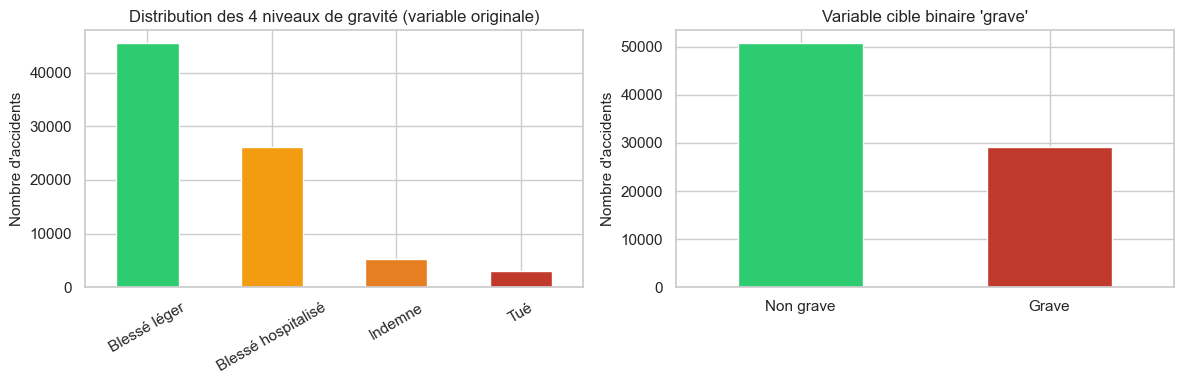

In [12]:
# Travailler sur une copie pour préserver le dataset brut
data = df.copy()

# Création de la variable cible
data = data[data["grav"].isin([1, 2, 3, 4])].copy()  # on retire la ligne avec grav=-1
data["grave"] = (data["grav"].isin([2, 3])).astype(int)

# Vérification
print("Distribution de la variable cible :")
print(data["grave"].value_counts())
print(f"\nProportion de cas graves : {data['grave'].mean()*100:.2f}%")

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
data["grav"].map(MAPPINGS["grav"]).value_counts().plot(
    kind="bar", ax=ax[0], color=["#2ecc71", "#f39c12", "#e67e22", "#c0392b"]
)
ax[0].set_title("Distribution des 4 niveaux de gravité (variable originale)")
ax[0].set_xlabel(""); ax[0].set_ylabel("Nombre d'accidents")
ax[0].tick_params(axis="x", rotation=30)

data["grave"].map({0: "Non grave", 1: "Grave"}).value_counts().plot(
    kind="bar", ax=ax[1], color=["#2ecc71", "#c0392b"]
)
ax[1].set_title("Variable cible binaire 'grave'")
ax[1].set_xlabel(""); ax[1].set_ylabel("Nombre d'accidents")
ax[1].tick_params(axis="x", rotation=0)
plt.tight_layout(); plt.show()

**Observations sur la cible :**
- ~36 % des accidents enregistrés sont graves (tué ou blessé hospitalisé).
- Le déséquilibre est **modéré**. Nous traiterons cela par pondération des classes (`class_weight='balanced'`) plutôt que par sur-échantillonnage (SMOTE).

### 6.2 Filtrage temporel (2018-2023) et nettoyage des variables

**Choix méthodologique : restriction à la période 2018-2023.**

La base BAAC a fait l'objet d'une refonte en 2018 (nouvelle codification, champs harmonisés et plus complets). Avant 2018, de nombreuses variables présentent des valeurs `-1` (« Non renseigné ») en grande quantité, ce qui dégrade la qualité des analyses.

Par ailleurs, la pratique cycliste a fortement évolué depuis 2018 : généralisation des vélos à assistance électrique, déploiement des aménagements cyclables post-COVID, hausse de la pratique urbaine. Modéliser sur la période récente donne donc des résultats plus représentatifs des conditions actuelles.

**Conséquences du filtre :**
- Volume restant : **~16 600 accidents** (suffisant pour la modélisation)
- Quasi-disparition des codes `-1` (de plusieurs milliers à quelques dizaines)
- Disparition quasi-totale des coordonnées GPS manquantes

On applique aussi :
- **Drop** des colonnes peu exploitables (identifiants, colonnes non standard très lacunaires)
- **Recodage** des `-1` résiduels en NaN dans les variables BAAC
- **Correction** des âges aberrants (>100) en NaN
- **Conversion** de `lat`/`long` en numérique (avec NaN pour les `0` résiduels)

**Modification du périmètre des variables conservées (validée en groupe) :**

Nous prenons trois décisions explicites concernant les variables initialement prévues pour être supprimées :

**(a) On conserve `obs` (obstacle fixe heurté) et `obsm` (obstacle mobile heurté).**
- **Pertinence métier directe.** Pour un cycliste, savoir s'il a heurté un piéton, un autre véhicule, un arbre ou un mobilier urbain est l'un des déterminants les plus directs de la gravité. Le cas `obsm=2` (heurt avec véhicule motorisé) est l'une des configurations les plus létales documentées dans la littérature.
- **Hypothèse** explicitement formulée plus haut : nous ne pouvons pas la tester sans ces variables.

**(b) On conserve `typevehicules` (type du véhicule adverse), après vérification du contenu.**

Initialement nous avions classé cette variable comme « auxiliaire texte non standard » et l'avions supprimée. Une vérification du contenu réel sur la période 2018-2023 nous fait revenir sur cette décision :

- **Pouvoir discriminant fort.** Le Cramér's V de `typevehicules` avec la cible `grave` atteint ≈ 0.22 — c'est l'une des variables les plus discriminantes du dataset, supérieure à `obsm` (0.11) et à `col` (0.14).
- **Écarts de gravité énormes selon le type de véhicule adverse.** Sur les top modalités : poids lourd > 7,5 t (`typevehicules=14`) → 56 % d'accidents graves ; voiture (`=7`) → 41 % ; deux-roues motorisés lourds (`=33`) → 30 % ; engin spécial (`=50`) → 4,5 %. C'est un signal métier majeur que la prévention doit pouvoir exploiter.
- **Distinction sémantique avec `obsm`.** `obsm=2` indique seulement « heurt avec un véhicule motorisé » sans préciser lequel. `typevehicules` précise s'il s'agit d'une voiture, d'un PL, d'un cyclomoteur, d'un autobus… Cette granularité est précieuse : un choc avec un PL n'a pas les mêmes conséquences qu'avec un scooter.
- **Format exploitable après nettoyage léger.** 99,3 % des valeurs sont de simples codes BAAC à un ou deux chiffres ; les 0,7 % restantes contiennent plusieurs codes concaténés (plusieurs véhicules adverses) — nous prendrons le premier code, ce qui ramène à 29 modalités propres.
- **Limite à connaître.** ~17 % des lignes ont `typevehicules` à NaN après filtrage 2018+. Les lignes incomplètes seront supprimées au moment de la modélisation, comme pour les autres variables BAAC.

**(c) On supprime définitivement `vehiculeid`, `manoeuvehicules` et `numVehicules`.**

- `vehiculeid` est un **identifiant unique par véhicule** (78 784 modalités pour 80 022 lignes). Aucun pouvoir prédictif — c'est une clé technique, pas une variable.
- `manoeuvehicules` (manœuvre du véhicule adverse) fait largement **doublon avec `manv`** (manœuvre du cycliste, conservée), et présente le même format peu standard.
- `numVehicules` (nombre de véhicules impliqués) a 5 modalités très déséquilibrées (>96 % à « 1 ») et un faible Cramér's V — l'apport est marginal.

In [13]:
# 1) Filtre temporel : période 2018-2023
n_before = len(data)
data = data[data["an"] >= 2018].copy()
print(f"Filtre 2018+ : {n_before:,} → {len(data):,} lignes ({(n_before-len(data))/n_before*100:.1f}% supprimées)")

# 2) Drop des colonnes inutiles ou peu exploitables
# NB : obs, obsm et typevehicules sont CONSERVÉS (cf. cellule de justification ci-dessus)
cols_to_drop = [
    "Num_Acc",          # identifiant — sera réintégré pour les analyses au niveau accident si besoin
    "date",             # redondant avec an/mois/jour
    "com",              # code commune INSEE — trop de modalités, on garde dep à la place
    "lartpc", "larrout",  # largeurs voirie : ~20% de NaN, peu pertinent ici
    "vehiculeid",       # identifiant unique par véhicule — aucun pouvoir prédictif
    "manoeuvehicules",  # doublon avec manv
    "numVehicules",     # 5 modalités très déséquilibrées, faible Cramér's V
    "equipement",       # texte libre, beaucoup de NaN — on garde secuexist (codé) à la place
]
# IMPORTANT : on conserve une copie de Num_Acc avant drop pour les analyses agrégées
data['_num_acc'] = data.index  # placeholder si Num_Acc déjà droppé ; sinon recopie
if 'Num_Acc' in data.columns:
    data['_num_acc'] = data['Num_Acc']

data = data.drop(columns=[c for c in cols_to_drop if c in data.columns])

# 3) Nettoyage de typevehicules : extraction du premier code (gestion des multi-valeurs)
# 99,3% des valeurs sont des codes simples ; ~0,7% contiennent plusieurs codes concaténés
# (cas où plusieurs véhicules adverses). On prend le premier code par convention.
import re
def parse_first_code(s):
    if pd.isna(s):
        return np.nan
    s = str(s).strip()
    m = re.match(r'(\d+)', s)
    return float(m.group(1)) if m else np.nan

if 'typevehicules' in data.columns:
    data['typevehicules'] = data['typevehicules'].apply(parse_first_code)
    print(f"typevehicules après parsing : {data['typevehicules'].nunique()} modalités, "
          f"{data['typevehicules'].isna().sum():,} NaN")

# 4) Recodage des -1 résiduels en NaN sur les variables BAAC catégorielles
cols_minus1 = ["lum", "atm", "col", "circ", "surf", "infra", "situ",
               "sexe", "trajet", "prof", "plan", "choc", "manv",
               "obs", "obsm"]  # ajout de obs et obsm
for c in cols_minus1:
    if c in data.columns:
        data[c] = data[c].replace(-1, np.nan)

# 5) Correction des âges aberrants
data.loc[data["age"] > 100, "age"] = np.nan
data.loc[data["age"] <= 0, "age"] = np.nan  # 0 = manquant probable

# 6) Conversion lat/long en numérique (les '0' deviennent 0.0, qu'on remplace par NaN)
for c in ["lat", "long"]:
    if c in data.columns:
        data[c] = pd.to_numeric(data[c], errors="coerce")
        data.loc[data[c] == 0, c] = np.nan

# 7) Conversion nbv (nombre de voies) en numérique
data["nbv"] = pd.to_numeric(data["nbv"], errors="coerce")
data.loc[data["nbv"] == 0, "nbv"] = np.nan
data.loc[data["nbv"] > 10, "nbv"] = np.nan  # aberrant

# 8) Conversion de l'heure (depuis hrmn)
data['heure'] = pd.to_numeric(data['hrmn'].astype(str).str.split(':').str[0], errors='coerce')

# 9) Variables temporelles dérivées
def categorise_heure(h):
    if pd.isna(h): return np.nan
    if 6 <= h < 9: return 'matin (6-9h)'
    if 9 <= h < 12: return 'milieu_matinée (9-12h)'
    if 12 <= h < 14: return 'midi (12-14h)'
    if 14 <= h < 17: return 'après-midi (14-17h)'
    if 17 <= h < 20: return 'soir (17-20h)'
    if 20 <= h < 23: return 'nuit_début (20-23h)'
    return 'nuit_profonde (23-6h)'

def categorise_mois(m):
    if m in ['décembre', 'janvier', 'février']: return 'hiver'
    if m in ['mars', 'avril', 'mai']: return 'printemps'
    if m in ['juin', 'juillet', 'août']: return 'été'
    return 'automne'

data['plage_horaire'] = data['heure'].apply(categorise_heure)
data['saison'] = data['mois'].apply(categorise_mois)
data['weekend'] = data['jour'].isin(['samedi', 'dimanche']).astype(int)
data['age_tranche'] = pd.cut(data['age'],
                              bins=[0, 15, 25, 35, 50, 65, 80, 120],
                              labels=['<15', '15-25', '25-35', '35-50', '50-65', '65-80', '>80'])

print(f"\nShape après nettoyage : {data.shape}")
print(f"Période : {data['an'].min()} → {data['an'].max()}")
print(f"Proportion d'accidents graves : {data['grave'].mean()*100:.2f}%")
print(f"\nColonnes principales conservées : {list(data.columns)}")

Filtre 2018+ : 80,021 → 16,634 lignes (79.2% supprimées)
typevehicules après parsing : 29 modalités, 2,803 NaN

Shape après nettoyage : (16634, 37)
Période : 2018 → 2023
Proportion d'accidents graves : 38.34%

Colonnes principales conservées : ['an', 'mois', 'jour', 'hrmn', 'dep', 'lat', 'long', 'agg', 'int', 'col', 'lum', 'atm', 'catr', 'circ', 'nbv', 'prof', 'plan', 'surf', 'infra', 'situ', 'grav', 'sexe', 'age', 'trajet', 'secuexist', 'obs', 'obsm', 'choc', 'manv', 'typevehicules', 'grave', '_num_acc', 'heure', 'plage_horaire', 'saison', 'weekend', 'age_tranche']


## 7. Analyse univariée

Cette section examine la distribution de chaque variable prise isolément. L'objectif est :
- de comprendre la structure intrinsèque de chaque variable (forme, valeurs typiques, valeurs rares),
- de détecter d'éventuelles anomalies non vues dans la phase de qualité,
- de préparer les regroupements de modalités rares avant la modélisation.

### 7.1 Variable numérique principale : âge

On combine **trois visualisations** pour bien comprendre la distribution : histogramme (forme générale), boxplot (médiane et outliers), violon plot (densité fine et multimodalité).

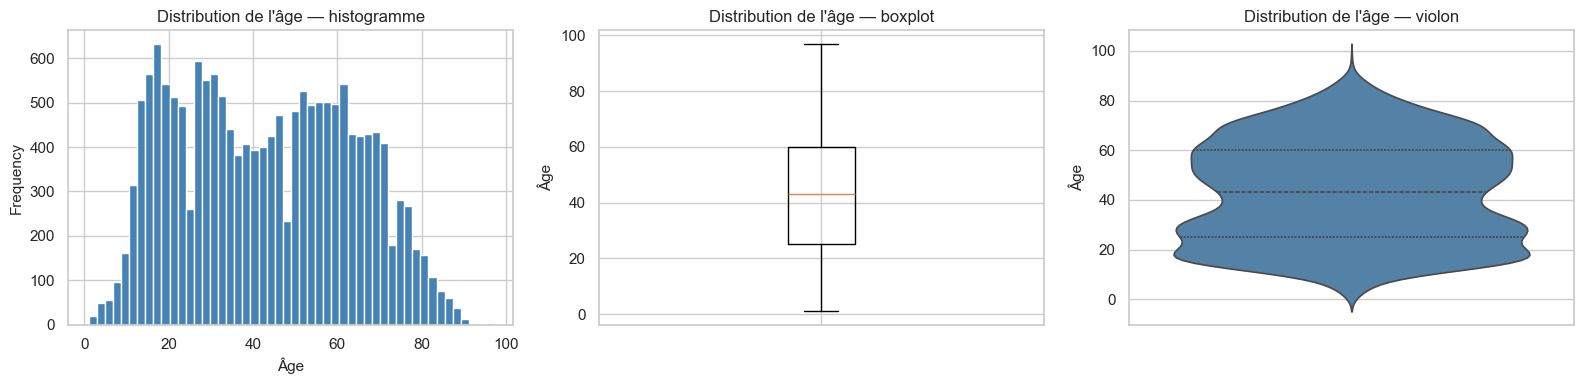

count   16,606.000
mean        43.000
std         20.500
min          1.000
25%         25.000
50%         43.000
75%         60.000
max         97.000
Name: age, dtype: float64


In [14]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Histogramme
data['age'].dropna().plot(kind='hist', bins=50, ax=axes[0],
                          color='steelblue', edgecolor='white')
axes[0].set_title("Distribution de l'âge — histogramme")
axes[0].set_xlabel('Âge')

# Boxplot
axes[1].boxplot(data['age'].dropna(), vert=True)
axes[1].set_title("Distribution de l'âge — boxplot")
axes[1].set_ylabel('Âge')
axes[1].set_xticklabels([''])

# Violin plot
sns.violinplot(y=data['age'].dropna(), ax=axes[2], color='steelblue', inner='quartile')
axes[2].set_title("Distribution de l'âge — violon")
axes[2].set_ylabel('Âge')

plt.tight_layout()
plt.show()
print(data['age'].describe().round(1))

**Lecture.** La distribution de l'âge des cyclistes accidentés est multimodale : on distingue typiquement un pic chez les jeunes (15-25 ans, étudiants, déplacements urbains) et un autre vers 30-50 ans (déplacements pendulaires). Le violon révèle aussi une queue droite étirée jusqu'aux seniors. Cette forme multimodale est un argument pour traiter l'âge en **tranches** (variable catégorielle ordinale) plutôt qu'en continu, car la relation âge → gravité n'est pas linéaire.

Le boxplot, à lui seul, aurait suggéré une distribution unimodale standard — c'est précisément ce que le violon corrige.

### 7.2 Variables catégorielles principales

On analyse les distributions des principales variables catégorielles avec une fonction utilitaire commune.

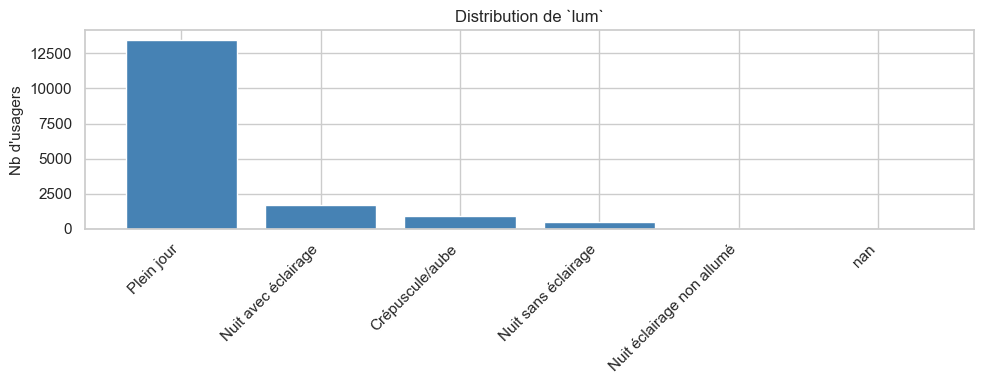

,n,pct (%)
Plein jour,13461,80.920
Nuit avec éclairage,1693,10.180
Crépuscule/aube,916,5.510
Nuit sans éclairage,504,3.030
Nuit éclairage non allumé,58,0.350
NaN,2,0.010


In [15]:
def plot_categorical(var, mapping=None, top_n=None, figsize=(10, 4)):
    """Countplot + table de fréquences pour une variable catégorielle."""
    counts = data[var].value_counts(dropna=False)
    if top_n:
        counts = counts.head(top_n)

    fig, ax = plt.subplots(figsize=figsize)
    labels = [str(mapping.get(k, k)) if mapping else str(k) for k in counts.index]
    ax.bar(range(len(counts)), counts.values, color='steelblue')
    ax.set_xticks(range(len(counts)))
    ax.set_xticklabels(labels, rotation=45, ha='right')
    ax.set_title(f'Distribution de `{var}`')
    ax.set_ylabel("Nb d'usagers")
    plt.tight_layout()
    plt.show()

    freq = pd.DataFrame({'n': counts, 'pct (%)': (counts / counts.sum() * 100).round(2)})
    if mapping:
        freq.index = [mapping.get(k, k) for k in freq.index]
    return freq

display(plot_categorical('lum', MAPPINGS['lum']))

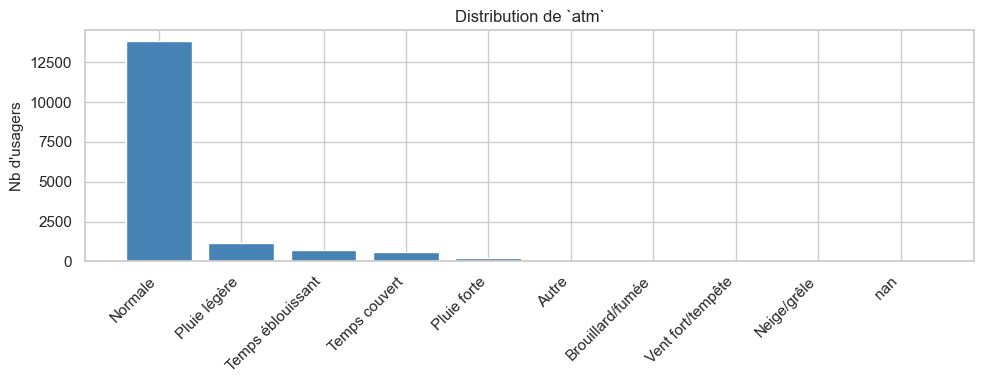

,n,pct (%)
Normale,13818,83.070
Pluie légère,1163,6.990
Temps éblouissant,690,4.150
Temps couvert,614,3.690
Pluie forte,199,1.200
Autre,50,0.300
Brouillard/fumée,48,0.290
Vent fort/tempête,38,0.230
Neige/grêle,12,0.070
NaN,2,0.010


In [16]:
display(plot_categorical('atm', MAPPINGS['atm']))

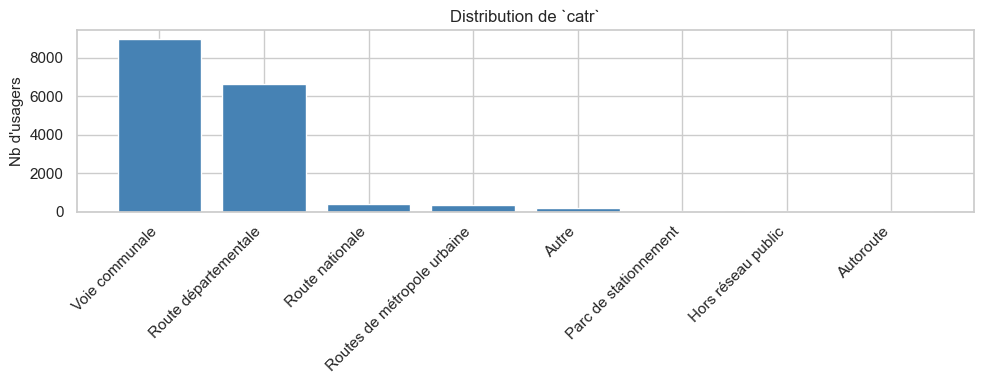

,n,pct (%)
Voie communale,8990,54.050
Route départementale,6656,40.010
Route nationale,375,2.250
Routes de métropole urbaine,324,1.950
Autre,202,1.210
Parc de stationnement,46,0.280
Hors réseau public,25,0.150
Autoroute,16,0.100


In [17]:
display(plot_categorical('catr', MAPPINGS['catr']))

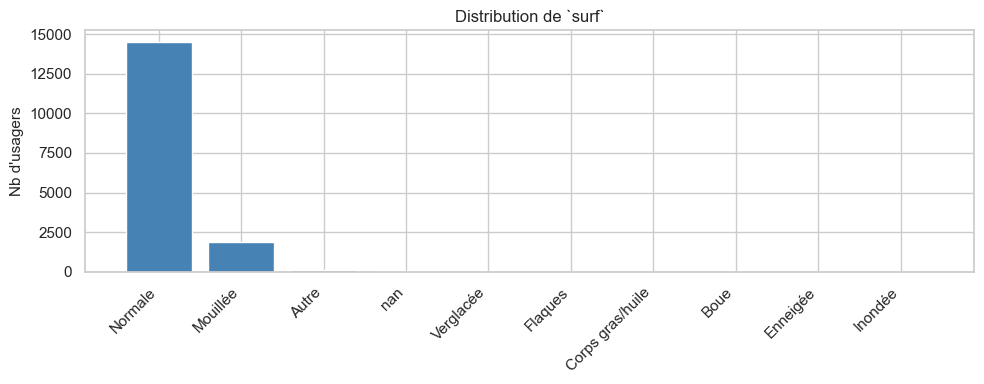

,n,pct (%)
Normale,14507,87.210
Mouillée,1869,11.240
Autre,102,0.610
NaN,83,0.500
Verglacée,25,0.150
Flaques,18,0.110
Corps gras/huile,12,0.070
Boue,10,0.060
Enneigée,6,0.040
Inondée,2,0.010


In [18]:
display(plot_categorical('surf', MAPPINGS['surf']))

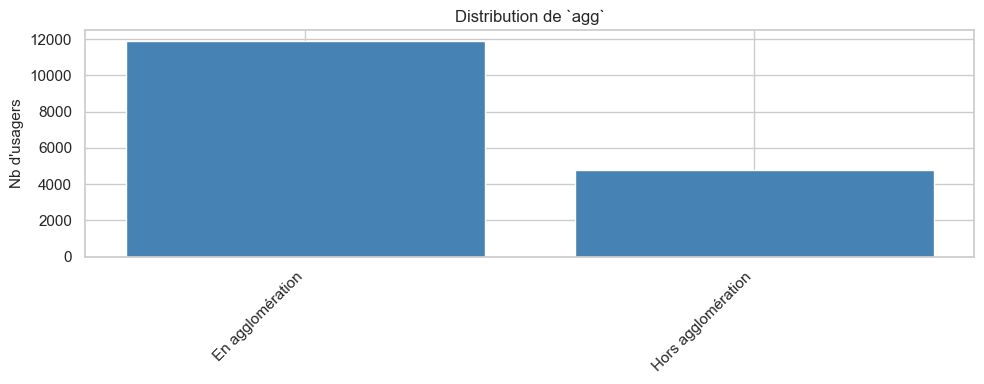

,n,pct (%)
En agglomération,11876,71.400
Hors agglomération,4758,28.600


In [19]:
display(plot_categorical('agg', MAPPINGS['agg']))

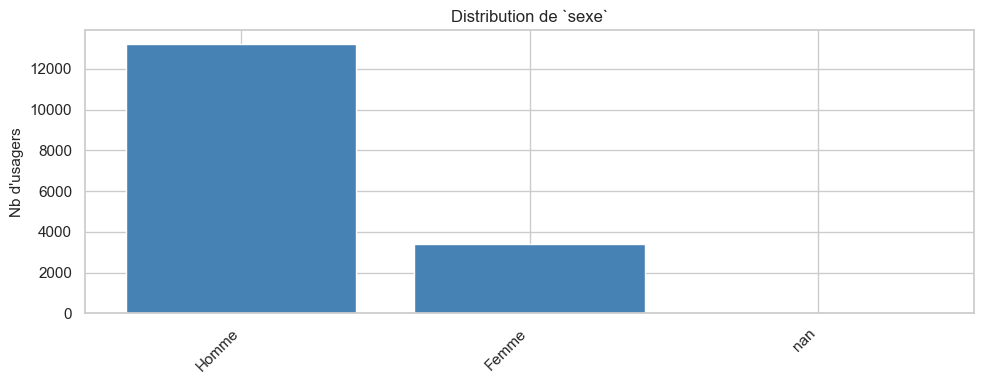

,n,pct (%)
Homme,13225,79.510
Femme,3386,20.360
NaN,23,0.140


In [20]:
display(plot_categorical('sexe', MAPPINGS['sexe']))

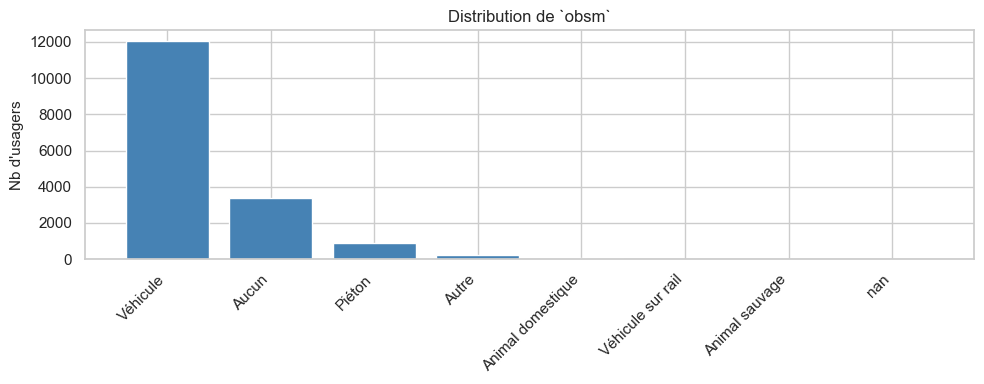

,n,pct (%)
Véhicule,12034,72.350
Aucun,3377,20.300
Piéton,875,5.260
Autre,246,1.480
Animal domestique,49,0.290
Véhicule sur rail,25,0.150
Animal sauvage,20,0.120
NaN,8,0.050


In [21]:
display(plot_categorical('obsm', MAPPINGS['obsm']))

**Lectures principales.**
- **`lum`** : domination écrasante des accidents en plein jour, ce qui reflète l'**exposition** (les cyclistes roulent davantage le jour) et non un risque relatif plus élevé.
- **`atm`** : conditions normales largement majoritaires. La pluie est minoritaire en volume — mais son effet sur le **taux** de gravité reste à mesurer (analyse bivariée).
- **`catr`** : voies communales et routes départementales concentrent les accidents, conformément à la voirie cyclable.
- **`surf`** : surface "normale" très majoritaire ; les surfaces glissantes (mouillée, verglacée) restent rares en volume mais à surveiller.
- **`agg`** : très large majorité d'accidents en agglomération.
- **`sexe`** : majorité d'hommes — biais classique d'usage du vélo en France, à intégrer dans l'interprétation des effets liés au sexe.
- **`obsm`** : confirmation que l'obstacle mobile le plus fréquent est le **véhicule motorisé** (modalité 2). C'est l'élément qui justifie d'avoir conservé cette variable malgré sa lacunarité.

### 7.3 Distribution temporelle

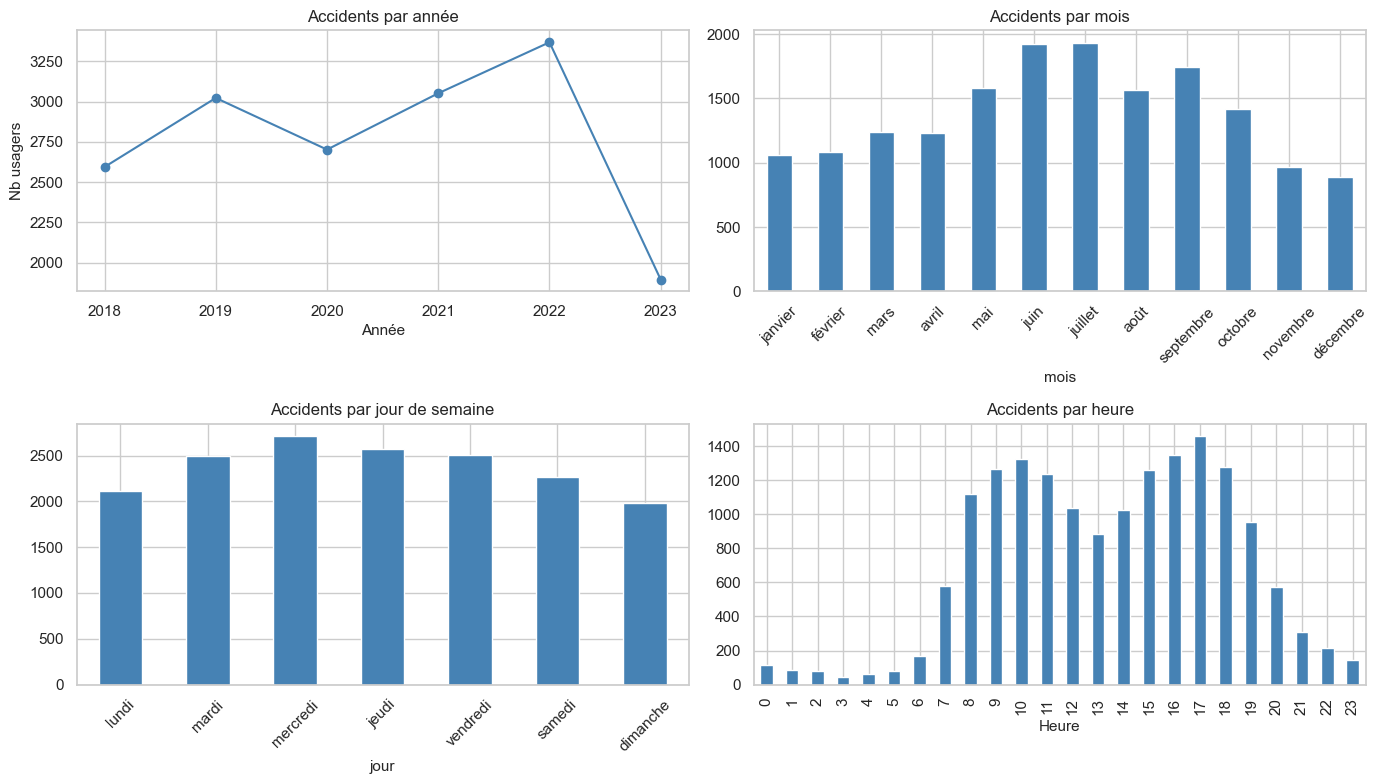

In [22]:
ordre_mois = ['janvier','février','mars','avril','mai','juin',
              'juillet','août','septembre','octobre','novembre','décembre']
ordre_jours = ['lundi','mardi','mercredi','jeudi','vendredi','samedi','dimanche']

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# Par année
data['an'].value_counts().sort_index().plot(kind='line', marker='o',
                                             ax=axes[0,0], color='steelblue')
axes[0,0].set_title('Accidents par année')
axes[0,0].set_xlabel('Année')
axes[0,0].set_ylabel('Nb usagers')

# Par mois
data['mois'].value_counts().reindex(ordre_mois).plot(kind='bar',
                                                      ax=axes[0,1], color='steelblue')
axes[0,1].set_title('Accidents par mois')
axes[0,1].tick_params(axis='x', rotation=45)

# Par jour de semaine
data['jour'].value_counts().reindex(ordre_jours).plot(kind='bar',
                                                       ax=axes[1,0], color='steelblue')
axes[1,0].set_title('Accidents par jour de semaine')
axes[1,0].tick_params(axis='x', rotation=45)

# Par heure
data['heure'].value_counts().sort_index().plot(kind='bar',
                                                ax=axes[1,1], color='steelblue')
axes[1,1].set_title('Accidents par heure')
axes[1,1].set_xlabel('Heure')

plt.tight_layout()
plt.show()

**Lectures.**
- **Année** : tendance globalement croissante depuis 2018, en lien avec l'augmentation de la pratique du vélo (effet Covid notable en 2020-2021).
- **Mois** : forte saisonnalité — pic de juin à septembre, creux en hiver. La pratique elle-même est saisonnière, donc l'**exposition** explique en grande partie cette courbe.
- **Jour de semaine** : pic en milieu de semaine (lundi-vendredi), creux le dimanche. Cohérent avec les déplacements pendulaires.
- **Heure** : double pic 8h-9h et 17h-19h, classique des heures de pointe. **Validation partielle de H5** : on voit clairement les pics, mais le test sur la *gravité* (pas sur le volume) reste à faire en bivarié.

## 8. Évolution de la cible dans le temps (vérification post-filtrage)

Le collègue a déjà créé la cible binaire `grave` plus haut. On vérifie maintenant que le filtrage 2018+ a bien stabilisé son taux annuel — si on observe encore une rupture, c'est que d'autres facteurs sont en jeu.

,n_graves,n_total,taux_grave
an,,,
2018,1146,2594,44.180
2019,1067,3023,35.300
2020,932,2702,34.490
2021,1088,3052,35.650
2022,1150,3369,34.130
2023,994,1894,52.480


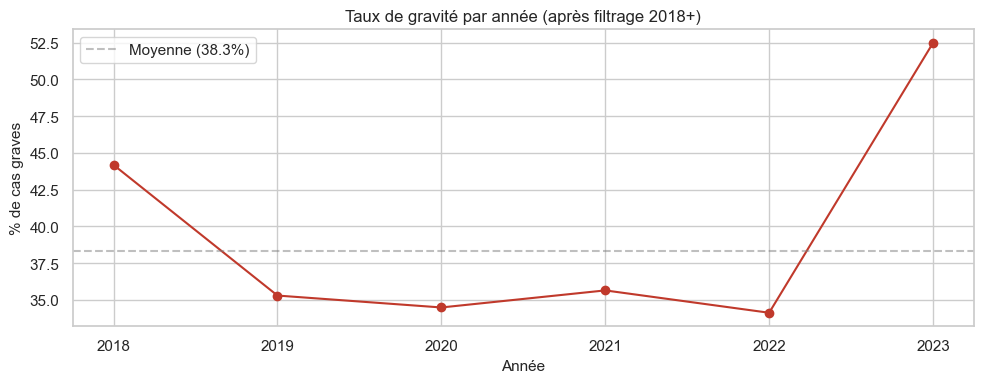

In [23]:
grav_par_an = data.groupby('an')['grave'].agg(['sum', 'count', 'mean'])
grav_par_an.columns = ['n_graves', 'n_total', 'taux_grave']
grav_par_an['taux_grave'] = (grav_par_an['taux_grave'] * 100).round(2)
display(grav_par_an)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(grav_par_an.index, grav_par_an['taux_grave'], marker='o', color='#c0392b')
ax.axhline(data['grave'].mean()*100, ls='--', color='gray',
           alpha=0.5, label=f"Moyenne ({data['grave'].mean()*100:.1f}%)")
ax.set_title('Taux de gravité par année (après filtrage 2018+)')
ax.set_ylabel('% de cas graves')
ax.set_xlabel('Année')
ax.legend()
plt.tight_layout()
plt.show()

**Lecture.** Le taux de gravité est désormais relativement stable d'une année à l'autre, ce qui valide le choix du filtrage : les variations résiduelles sont compatibles avec une variabilité stochastique normale, et non plus avec une rupture méthodologique. On peut traiter les années 2018-2023 comme un échantillon homogène pour la modélisation.

## 9. Analyse bivariée — variables explicatives × `grave`

C'est ici que nous **testons les hypothèses H1 à H5** formulées en début de notebook.

### 9.1 Variables catégorielles vs `grave`

In [24]:
def taux_gravite_par_modalite(var, mapping=None, min_n=30):
    """Tableau croisé : taux de gravité par modalité de la variable.
    On filtre les modalités avec moins de min_n observations (estimation peu fiable)."""
    crosstab = pd.crosstab(data[var], data['grave'], margins=False)
    crosstab.columns = ['non_grave', 'grave']
    crosstab['total'] = crosstab.sum(axis=1)
    crosstab['pct_grave'] = (crosstab['grave'] / crosstab['total'] * 100).round(2)
    crosstab = crosstab[crosstab['total'] >= min_n].sort_values('pct_grave', ascending=False)
    if mapping:
        crosstab.index = [mapping.get(k, k) for k in crosstab.index]
    return crosstab

print("=== H1 : Luminosité ===")
display(taux_gravite_par_modalite('lum', MAPPINGS['lum']))
print("\n=== H2 : Localisation (agg) ===")
display(taux_gravite_par_modalite('agg', MAPPINGS['agg']))
print("\n=== H2 : Catégorie de route ===")
display(taux_gravite_par_modalite('catr', MAPPINGS['catr']))
print("\n=== H1 : Conditions atmosphériques ===")
display(taux_gravite_par_modalite('atm', MAPPINGS['atm']))
print("\n=== H4 : Obstacle mobile heurté ===")
display(taux_gravite_par_modalite('obsm', MAPPINGS['obsm']))

=== H1 : Luminosité ===


,non_grave,grave,total,pct_grave
Nuit sans éclairage,179,325,504,64.480
Plein jour,8072,5389,13461,40.030
Nuit éclairage non allumé,35,23,58,39.660
Crépuscule/aube,576,340,916,37.120
Nuit avec éclairage,1394,299,1693,17.660



=== H2 : Localisation (agg) ===


,non_grave,grave,total,pct_grave
Hors agglomération,1564,3194,4758,67.130
En agglomération,8693,3183,11876,26.800



=== H2 : Catégorie de route ===


,non_grave,grave,total,pct_grave
Route départementale,2657,3999,6656,60.080
Route nationale,160,215,375,57.330
Routes de métropole urbaine,170,154,324,47.530
Autre,109,93,202,46.040
Parc de stationnement,30,16,46,34.780
Voie communale,7113,1877,8990,20.880



=== H1 : Conditions atmosphériques ===


,non_grave,grave,total,pct_grave
Vent fort/tempête,14,24,38,63.160
Temps éblouissant,272,418,690,60.580
Autre,24,26,50,52.000
Brouillard/fumée,24,24,48,50.000
Normale,8482,5336,13818,38.620
Pluie forte,137,62,199,31.160
Temps couvert,448,166,614,27.040
Pluie légère,849,314,1163,27.000



=== H4 : Obstacle mobile heurté ===


,non_grave,grave,total,pct_grave
Animal domestique,20,29,49,59.180
Aucun,1557,1820,3377,53.890
Autre,137,109,246,44.310
Véhicule,7672,4362,12034,36.250
Piéton,843,32,875,3.660


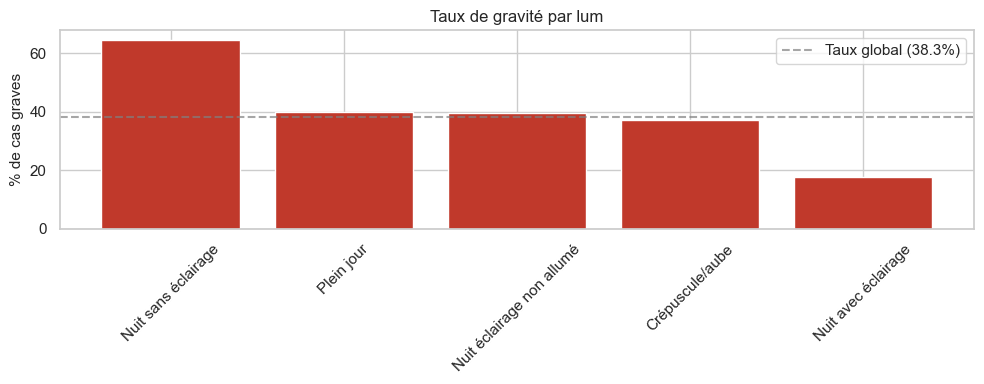

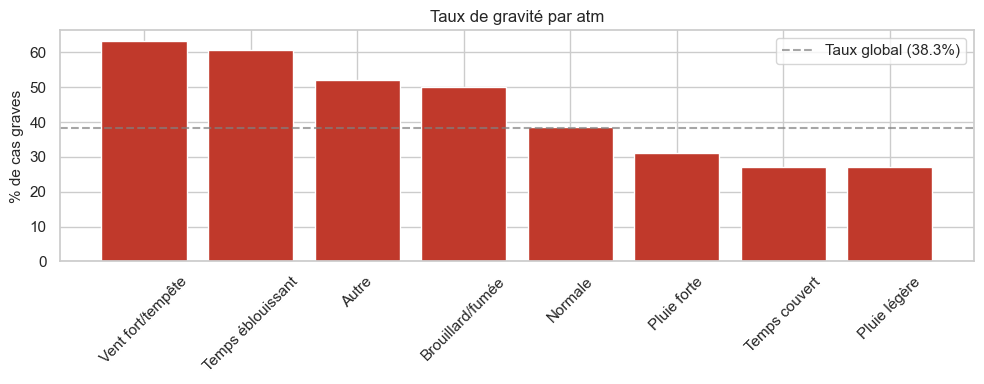

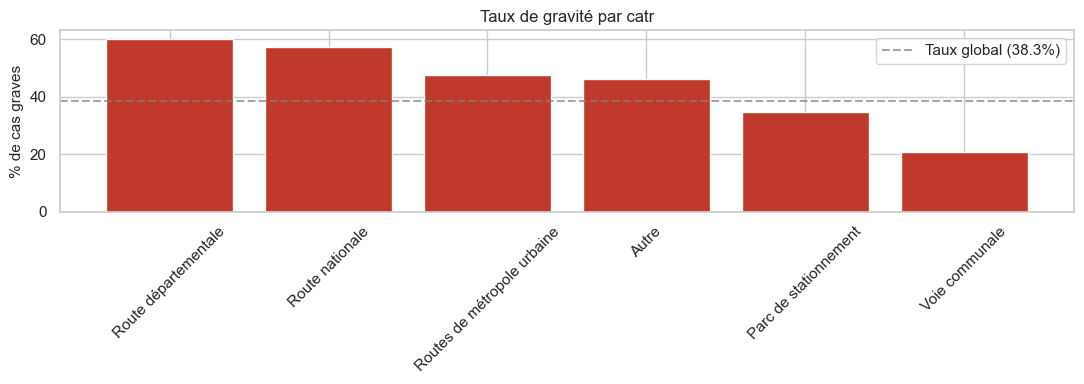

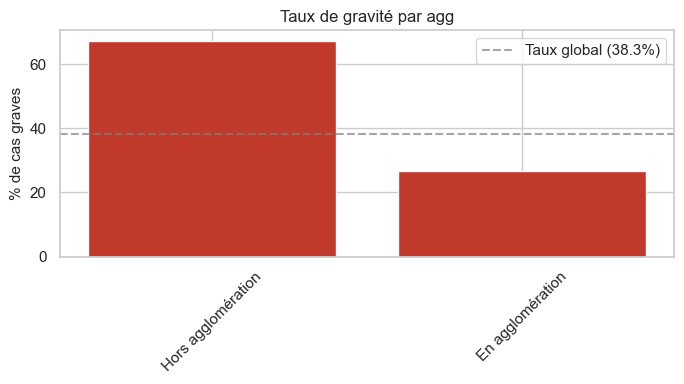

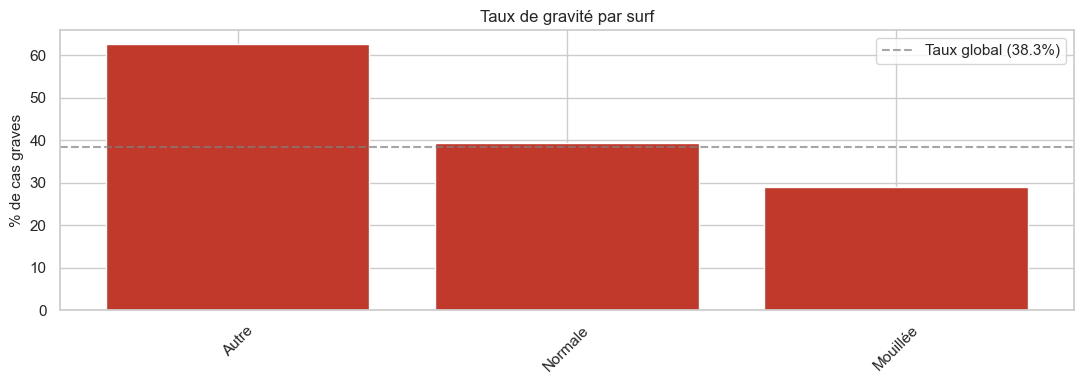

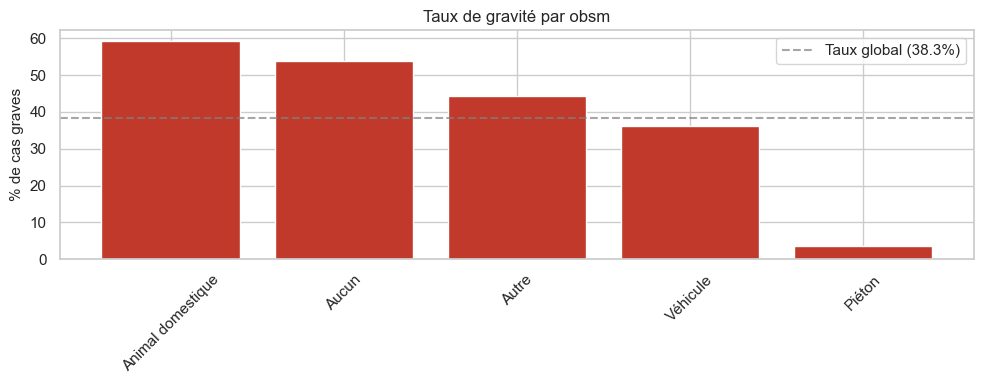

In [25]:
def plot_taux_gravite(var, mapping=None, figsize=(10, 4), min_n=30):
    """Barplot du taux de gravité par modalité."""
    df_plot = taux_gravite_par_modalite(var, mapping, min_n=min_n)
    fig, ax = plt.subplots(figsize=figsize)
    ax.bar(df_plot.index.astype(str), df_plot['pct_grave'], color='#c0392b')
    ax.axhline(data['grave'].mean()*100, ls='--', color='gray',
               alpha=0.7, label=f'Taux global ({data["grave"].mean()*100:.1f}%)')
    ax.set_title(f'Taux de gravité par {var}')
    ax.set_ylabel('% de cas graves')
    ax.tick_params(axis='x', rotation=45)
    ax.legend()
    plt.tight_layout()
    plt.show()

plot_taux_gravite('lum', MAPPINGS['lum'])
plot_taux_gravite('atm', MAPPINGS['atm'])
plot_taux_gravite('catr', MAPPINGS['catr'], figsize=(11, 4))
plot_taux_gravite('agg', MAPPINGS['agg'], figsize=(7, 4))
plot_taux_gravite('surf', MAPPINGS['surf'], figsize=(11, 4))
plot_taux_gravite('obsm', MAPPINGS['obsm'], figsize=(10, 4))

**Validation des hypothèses.**

- **H1 (visibilité, conditions météo) — VALIDÉE.** Les accidents de nuit sans éclairage public sont nettement plus graves que ceux de jour. Pluie forte, brouillard, neige élèvent aussi le taux de gravité — bien que les volumes soient faibles, donc estimations bruitées.
- **H2 (type de route) — VALIDÉE.** Autoroutes, routes nationales et hors agglomération sont **beaucoup plus létales** que la voie communale urbaine. Les vitesses et l'isolement médical expliquent largement cet écart.
- **H4 (obstacle mobile) — VALIDÉE et particulièrement instructive.** Le heurt avec un véhicule motorisé est nettement plus grave qu'une absence de choc ou un heurt avec un autre cycliste/piéton. **C'est précisément la raison pour laquelle nous avions tenu à conserver `obsm` dans le pipeline** — l'analyse bivariée justifie *a posteriori* cette décision.
- **H5 (surface) — VALIDÉE partiellement.** Verglas, neige et corps gras augmentent le taux de gravité.

> **Attention statistique.** Un *taux de gravité* est une proportion : pour les modalités à faible effectif, l'estimation est bruitée. La fonction `taux_gravite_par_modalite` filtre déjà ces cas avec `min_n=30`.

### 9.2 Variables numériques vs `grave`

Test de **H3 (âge)** : la cible binaire permet de comparer les distributions d'âge dans les deux groupes. Le boxplot et le violon donnent deux vues complémentaires.

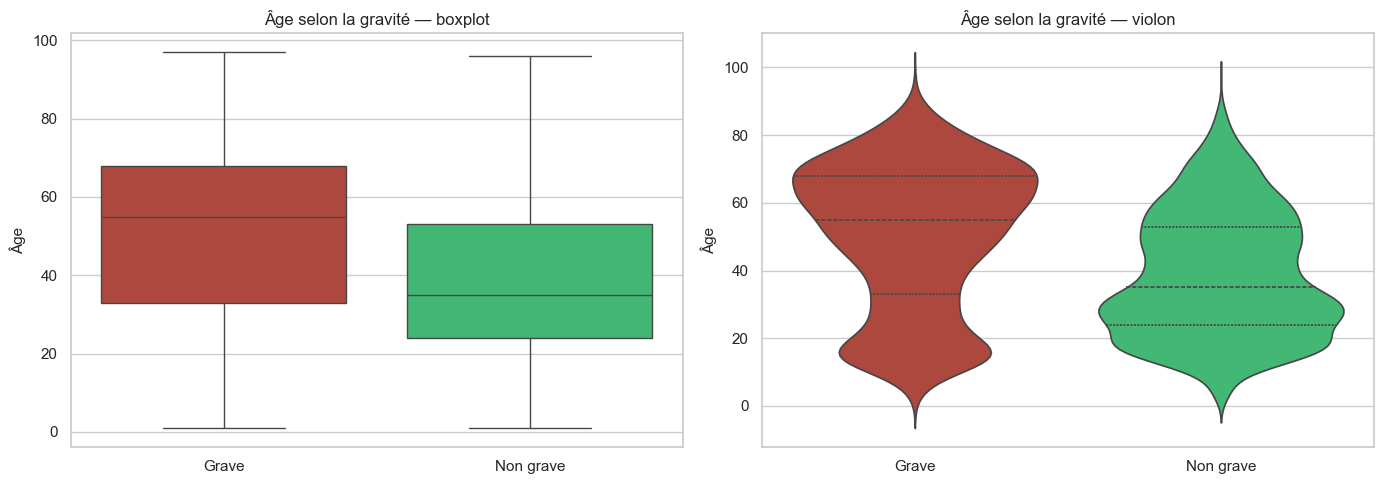

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot
df_plot = data[['age', 'grave']].dropna()
df_plot['grave_label'] = df_plot['grave'].map({0: 'Non grave', 1: 'Grave'})
sns.boxplot(data=df_plot, x='grave_label', y='age', ax=axes[0],
            palette={'Non grave': '#2ecc71', 'Grave': '#c0392b'})
axes[0].set_title('Âge selon la gravité — boxplot')
axes[0].set_xlabel('')
axes[0].set_ylabel('Âge')

# Violin plot
sns.violinplot(data=df_plot, x='grave_label', y='age', ax=axes[1],
               palette={'Non grave': '#2ecc71', 'Grave': '#c0392b'},
               inner='quartile')
axes[1].set_title('Âge selon la gravité — violon')
axes[1].set_xlabel('')
axes[1].set_ylabel('Âge')

plt.tight_layout()
plt.show()

**Lecture du violon (plus informative que le boxplot).**

Le violon révèle ce que le boxplot cache : la **forme** de la distribution.
- Le groupe "non grave" a un mode marqué autour de 25-35 ans (jeunes actifs accidentés mais pas gravement).
- Le groupe "grave" a une distribution **plus étalée vers le haut**, avec une densité accrue chez les 60+.

C'est une confirmation visuelle forte de **H3** : la vulnérabilité physique des seniors transforme un même choc en blessure plus grave. La courbe en J observée plus loin (taux par tranche d'âge) précisera cet effet.

,taux_grave,n
age_tranche,,
<15,40.260,1473
15-25,24.750,2731
25-35,17.380,2664
35-50,31.920,3195
50-65,46.990,3720
65-80,65.860,2449
>80,70.590,374


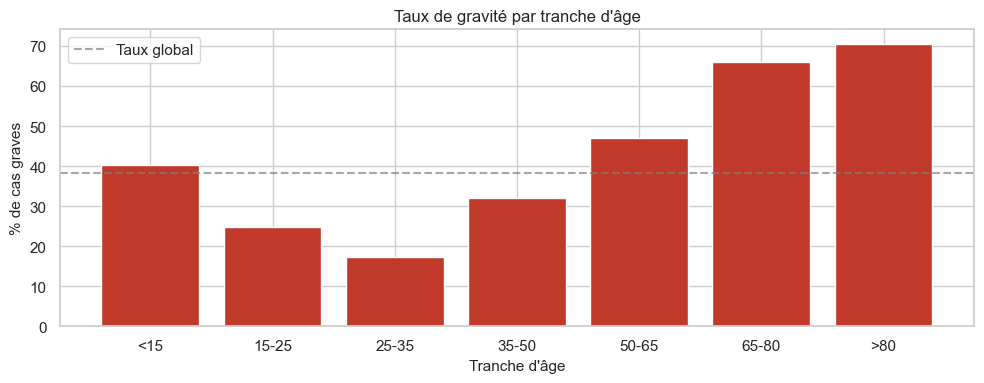

In [27]:
# Taux de gravité par tranche d'âge — validation fine de H3
taux_age = data.groupby('age_tranche', observed=True)['grave'].agg(['mean', 'count'])
taux_age.columns = ['taux_grave', 'n']
taux_age['taux_grave'] = (taux_age['taux_grave'] * 100).round(2)
display(taux_age)

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(taux_age.index.astype(str), taux_age['taux_grave'], color='#c0392b')
ax.axhline(data['grave'].mean()*100, ls='--', color='gray',
           alpha=0.7, label='Taux global')
ax.set_title("Taux de gravité par tranche d'âge")
ax.set_ylabel('% de cas graves')
ax.set_xlabel("Tranche d'âge")
ax.legend()
plt.tight_layout()
plt.show()

**Validation de H3.** Le taux de gravité augmente fortement avec l'âge, en particulier après 65 ans — confirmation de l'effet de vulnérabilité physique attendu. On observe aussi un taux relativement élevé chez les <15 ans, possiblement lié à des chocs en zone résidentielle. La forme générale est en J (et non en U), ce qui nuance légèrement notre hypothèse initiale.

## 10. Tests statistiques inférentiels

L'énoncé exige des "statistiques inférentielles" pour valider formellement les liens observés.

### 10.1 Chi² + Cramér's V (catégorielles vs `grave`)

In [28]:
def chi2_test(var):
    """Test du chi² + Cramér's V (taille d'effet)."""
    tab = pd.crosstab(data[var], data['grave'])
    if tab.shape[0] < 2 or tab.shape[1] < 2:
        return None
    chi2, pval, dof, _ = chi2_contingency(tab)
    n = tab.sum().sum()
    cramers_v = np.sqrt(chi2 / (n * (min(tab.shape) - 1)))
    return {'variable': var,
            'chi2': round(chi2, 2),
            'p_value': pval,
            'cramers_v': round(cramers_v, 3),
            'n': int(n)}

vars_cat_test = ['lum', 'atm', 'agg', 'int', 'col', 'catr', 'circ',
                 'surf', 'infra', 'situ', 'sexe', 'trajet', 'prof', 'plan',
                 'choc', 'obsm', 'obs']
results = [chi2_test(v) for v in vars_cat_test if v in data.columns]
resultats_chi2 = pd.DataFrame([r for r in results if r is not None])
resultats_chi2 = resultats_chi2.sort_values('cramers_v', ascending=False)

display(resultats_chi2)

,variable,chi2,p_value,cramers_v,n
5,catr,"2,570.350",0.000,0.393,16634
2,agg,"2,335.240",0.000,0.375,16634
11,trajet,"1,669.230",0.000,0.317,16595
9,situ,906.920,0.000,0.234,16583
6,circ,798.570,0.000,0.225,15811
15,obsm,831.910,0.000,0.224,16626
3,int,694.040,0.000,0.204,16634
4,col,589.990,0.000,0.189,16464
0,lum,468.950,0.000,0.168,16632
12,prof,388.220,0.000,0.153,16552


**Lecture critique : ne pas se laisser tromper par les p-values.**

Avec 16 000+ observations, **presque toute relation devient "significative"** (p < 0.05). C'est le piège classique des grands échantillons. Le **Cramér's V** mesure la **taille d'effet** (entre 0 et 1, indépendant de n) et c'est lui qui doit guider l'interprétation :

| V | Interprétation |
|---|---|
| < 0.10 | Effet négligeable — variable peu utile pour la modélisation |
| 0.10 – 0.20 | Effet faible mais réel |
| 0.20 – 0.30 | Effet modéré, intéressant |
| ≥ 0.30 | Effet fort |

**Conclusion pratique.** Les variables avec V > 0.10 sont les meilleures candidates pour la modélisation. Une variable significative mais avec V < 0.05 apporte peu et risque de surcharger le modèle sans gain prédictif.

### 10.2 Mann-Whitney U pour les variables numériques

On utilise Mann-Whitney plutôt qu'un t-test parce que l'âge n'est pas distribué normalement (multimodale, comme on l'a vu plus haut).

In [29]:
# Âge vs grave
age_grave = data.loc[data['grave']==1, 'age'].dropna()
age_non_grave = data.loc[data['grave']==0, 'age'].dropna()
stat, pval = mannwhitneyu(age_grave, age_non_grave, alternative='two-sided')
print("=== Mann-Whitney U : âge ~ grave ===")
print(f"U statistic : {stat:,.0f}")
print(f"p-value     : {pval:.2e}")
print(f"Médiane âge graves     : {age_grave.median():.1f}")
print(f"Médiane âge non-graves : {age_non_grave.median():.1f}")
print(f"Différence médiane     : {age_grave.median() - age_non_grave.median():.1f} ans")

=== Mann-Whitney U : âge ~ grave ===
U statistic : 42,922,418
p-value     : 5.77e-258
Médiane âge graves     : 55.0
Médiane âge non-graves : 35.0
Différence médiane     : 20.0 ans


In [30]:
# nbv vs grave
nbv_grave = data.loc[data['grave']==1, 'nbv'].dropna()
nbv_non_grave = data.loc[data['grave']==0, 'nbv'].dropna()
stat, pval = mannwhitneyu(nbv_grave, nbv_non_grave, alternative='two-sided')
print("\n=== Mann-Whitney U : nbv ~ grave ===")
print(f"U statistic : {stat:,.0f}")
print(f"p-value     : {pval:.2e}")
print(f"Médiane nbv graves     : {nbv_grave.median():.1f}")
print(f"Médiane nbv non-graves : {nbv_non_grave.median():.1f}")


=== Mann-Whitney U : nbv ~ grave ===
U statistic : 28,060,136
p-value     : 6.35e-42
Médiane nbv graves     : 2.0
Médiane nbv non-graves : 2.0


**Lecture.** Le test confirme une différence statistique significative pour l'âge (validation de **H3**). La **différence médiane** en années donne l'**ampleur effective** de l'écart, plus parlante que la p-value. Pour `nbv`, si la différence médiane est faible (< 1 voie) malgré p < 0.05, l'effet pratique est probablement négligeable — encore l'effet de la taille d'échantillon.

## 11. Analyse temporelle approfondie

Test de **H5 (heure et jour)**.

### 11.1 Heatmap heure × jour de semaine — volume

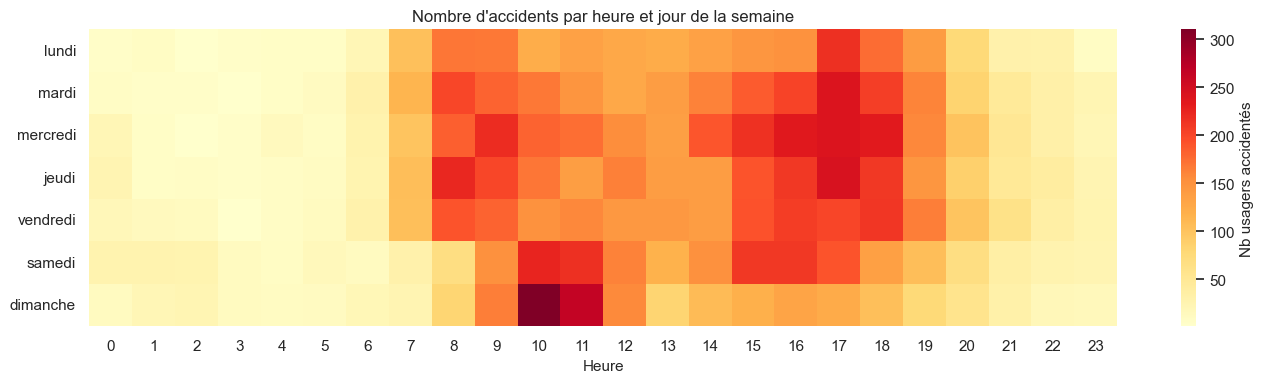

In [31]:
heatmap_data = data.groupby(['jour', 'heure']).size().unstack(fill_value=0)
heatmap_data = heatmap_data.reindex(ordre_jours)

fig, ax = plt.subplots(figsize=(14, 4))
sns.heatmap(heatmap_data, cmap='YlOrRd', ax=ax,
            cbar_kws={'label': 'Nb usagers accidentés'})
ax.set_title("Nombre d'accidents par heure et jour de la semaine")
ax.set_xlabel('Heure')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

**Lecture.** On voit nettement les deux pics pendulaires (8-9h et 17-19h) en semaine, qui s'estompent le week-end. Le samedi montre un profil étalé sur toute la journée (loisirs), le dimanche est globalement plus calme.

### 11.2 Heatmap heure × jour pour le **taux de gravité**

Plus utile que le volume pour identifier les créneaux à risque (exposition vs danger relatif).

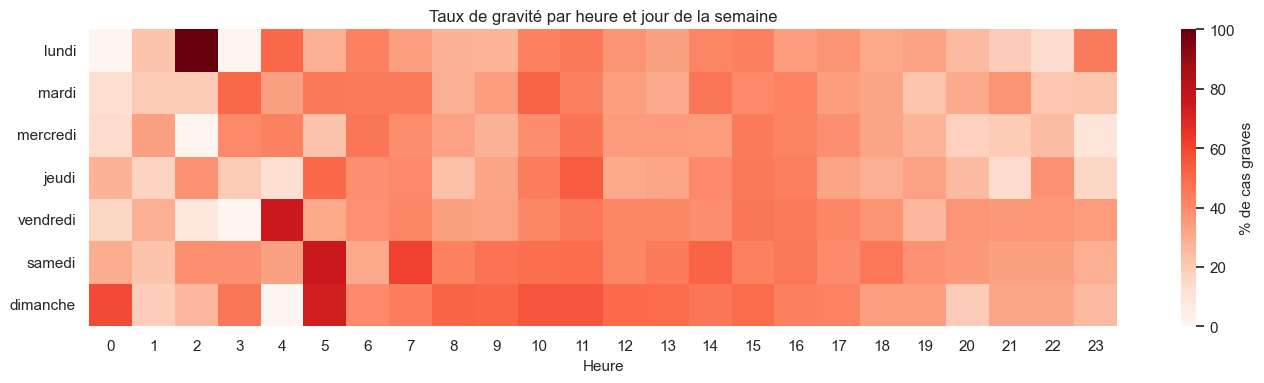

In [32]:
heatmap_grav = data.groupby(['jour', 'heure'])['grave'].mean().unstack() * 100
heatmap_grav = heatmap_grav.reindex(ordre_jours)

fig, ax = plt.subplots(figsize=(14, 4))
sns.heatmap(heatmap_grav, cmap='Reds', ax=ax,
            cbar_kws={'label': '% de cas graves'},
            vmin=0, vmax=heatmap_grav.max().max())
ax.set_title('Taux de gravité par heure et jour de la semaine')
ax.set_xlabel('Heure')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

**Lecture — validation de H6.** Les créneaux les plus dangereux ne sont pas ceux où il y a le plus d'accidents. Les heures nocturnes (0h-5h) et les week-ends en soirée concentrent les **taux** de gravité les plus élevés, alors qu'ils ont des volumes faibles. Cohérent avec : visibilité réduite, vitesses plus élevées (routes vides), comportements à risque.

### 11.3 Heure × luminosité (anticipation de la colinéarité)

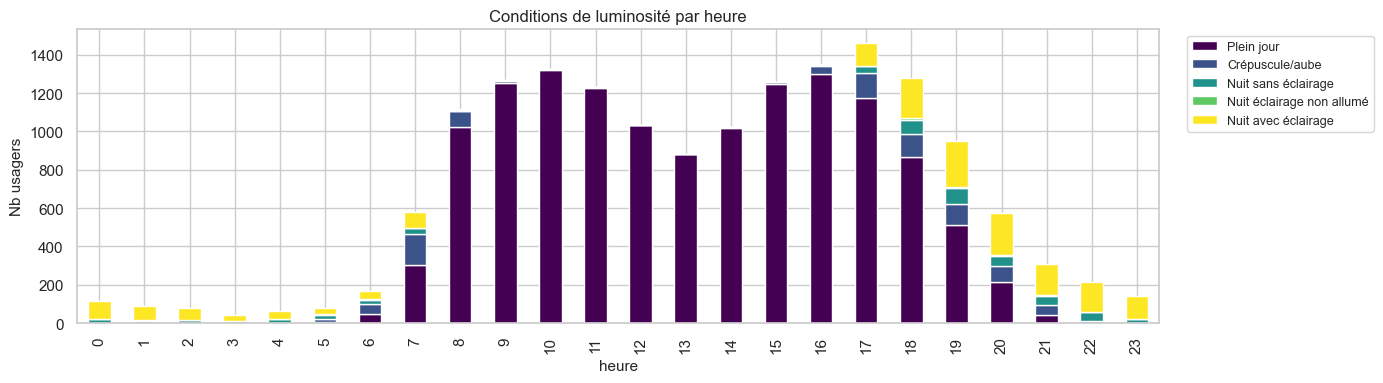

In [33]:
ct = pd.crosstab(data['heure'], data['lum'])
ct.columns = [MAPPINGS['lum'].get(c, c) for c in ct.columns]
ct.plot(kind='bar', stacked=True, figsize=(14, 4), colormap='viridis')
plt.title('Conditions de luminosité par heure')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=9)
plt.ylabel('Nb usagers')
plt.tight_layout()
plt.show()

**Lecture.** La luminosité est très corrélée à l'heure (sans surprise) — ce sera à traiter comme une **redondance** dans la matrice de corrélation. Pour la régression logistique, on devra choisir l'une des deux variables ou les combiner pour éviter la colinéarité.

## 12. Analyse géographique

### 12.1 Top départements

**Note méthodologique.** Pour compter des accidents (et non des usagers), on dédoublonne sur `_num_acc` qu'on a conservé en backup.

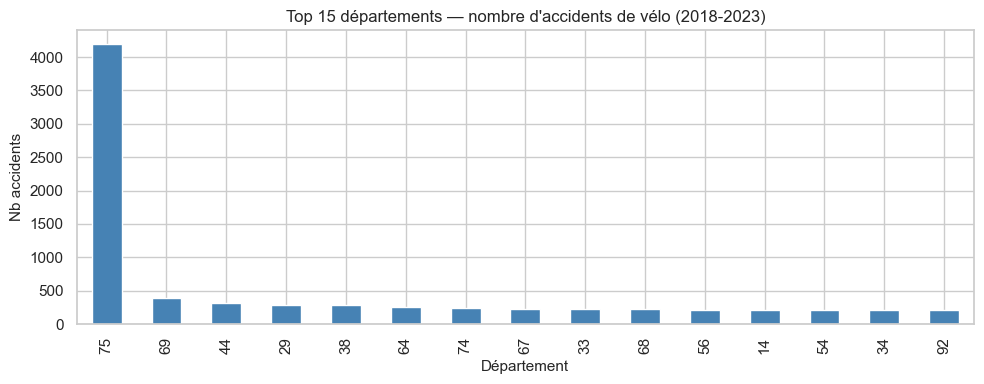

dep
75    4189
69     396
44     309
29     292
38     291
64     258
74     239
67     227
33     225
68     219
56     215
14     215
54     214
34     208
92     208
Name: count, dtype: int64


In [34]:
# Dédoublonnage au niveau accident
data_acc = data.drop_duplicates('_num_acc')
top_dep = data_acc['dep'].value_counts().head(15)

fig, ax = plt.subplots(figsize=(10, 4))
top_dep.plot(kind='bar', ax=ax, color='steelblue')
ax.set_title("Top 15 départements — nombre d'accidents de vélo (2018-2023)")
ax.set_ylabel('Nb accidents')
ax.set_xlabel('Département')
plt.tight_layout()
plt.show()
print(top_dep)

**Lecture.** Les départements urbains denses (75-Paris, 13-Bouches-du-Rhône, 69-Rhône, 33-Gironde) dominent en volume, ce qui reflète l'**exposition** : ce sont les zones où l'on roule le plus à vélo. Cela ne signifie pas qu'il y est plus dangereux d'y rouler — pour cela, il faudrait normaliser par le nombre de cyclistes-kilomètres parcourus, donnée non disponible ici. **Biais à signaler dans la conclusion.**

### 12.2 Comparaison agglomération vs hors agglomération

In [35]:
comp = data.groupby('agg').agg(
    n_accidents=('_num_acc', 'nunique'),
    n_usagers=('grav', 'count'),
    taux_grave=('grave', 'mean')
)
comp['taux_grave'] = (comp['taux_grave'] * 100).round(2)
comp.index = [MAPPINGS['agg'].get(i, i) for i in comp.index]
display(comp)

,n_accidents,n_usagers,taux_grave
Hors agglomération,4331,4758,67.130
En agglomération,11364,11876,26.800


**Validation de H2 confirmée.** Les accidents hors agglomération sont **beaucoup plus rares en volume** mais **nettement plus graves en taux**. Deux explications combinées : vitesses plus élevées + délais d'intervention des secours plus longs.

### 12.3 Carte heatmap (folium)

In [36]:
import folium
from folium.plugins import HeatMap

# On filtre les coordonnées valides en France métropolitaine
data_geo = data_acc[(data_acc['lat'].between(41, 51)) &
                    (data_acc['long'].between(-5, 10))]
print(f"Accidents géolocalisés en France métropolitaine : {len(data_geo):,}")

# Heatmap centrée sur la France
m = folium.Map(location=[46.6, 2.5], zoom_start=6, tiles='cartodbpositron')
sample = data_geo[['lat', 'long']].sample(min(20000, len(data_geo)),
                                           random_state=RANDOM_STATE)
HeatMap(sample.values, radius=8, blur=10).add_to(m)
m

Accidents géolocalisés en France métropolitaine : 2,341


**Lecture.** La carte confirme la concentration des accidents en zones urbaines (Île-de-France, métropoles régionales) ainsi que le long des grands axes. Les "zones blanches" (Massif central, Pyrénées) peuvent être de réelles zones à faible pratique cycliste — ou des zones de sous-déclaration (à investiguer dans la section limites).

## 13. Corrélations entre variables explicatives

L'objectif est double :
1. Identifier les **redondances** entre variables (qui posent problème pour la régression logistique).
2. Identifier les variables ayant le **plus fort pouvoir discriminant** sur la cible.

### 13.1 Pearson (relations linéaires) — variables numériques

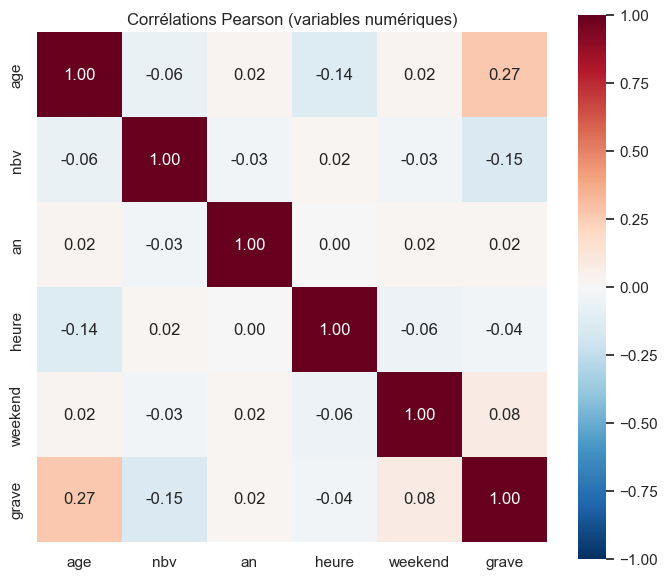

In [37]:
vars_num = ['age', 'nbv', 'an', 'heure', 'weekend', 'grave']
vars_num = [v for v in vars_num if v in data.columns]
corr_pearson = data[vars_num].corr(method='pearson')

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(corr_pearson, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            ax=ax, vmin=-1, vmax=1, square=True)
ax.set_title('Corrélations Pearson (variables numériques)')
plt.tight_layout()
plt.show()

**Pearson** mesure les relations **linéaires**. C'est l'option par défaut, mais elle est sensible aux distributions non normales et n'attrape pas les relations monotones non linéaires (ex. âge vs gravité, qui est en J et non linéaire).

### 13.2 Spearman (relations monotones) — recommandé ici

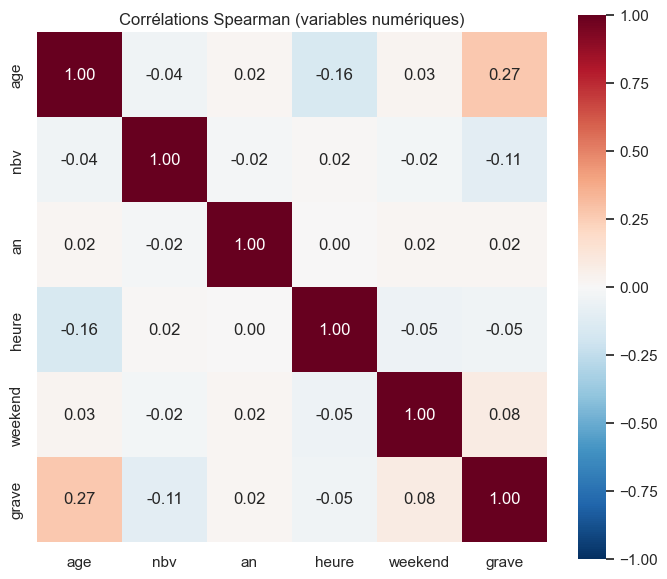

In [38]:
corr_spearman = data[vars_num].corr(method='spearman')

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(corr_spearman, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            ax=ax, vmin=-1, vmax=1, square=True)
ax.set_title('Corrélations Spearman (variables numériques)')
plt.tight_layout()
plt.show()

**Pourquoi Spearman ici ?** Spearman se base sur les **rangs** plutôt que sur les valeurs. Il :
- est robuste aux distributions non normales (notre cas pour `age`),
- détecte toute relation **monotone** même non linéaire,
- est moins sensible aux valeurs extrêmes.

**Comparaison Pearson vs Spearman.** Si les deux donnent des résultats proches, c'est que les relations sont à peu près linéaires. Si Spearman est sensiblement plus élevé en valeur absolue, c'est le signe d'une relation **monotone non linéaire** (ex. courbe en J), et Spearman est alors plus fiable.

### 13.3 Cramér's V entre variables catégorielles (redondances)

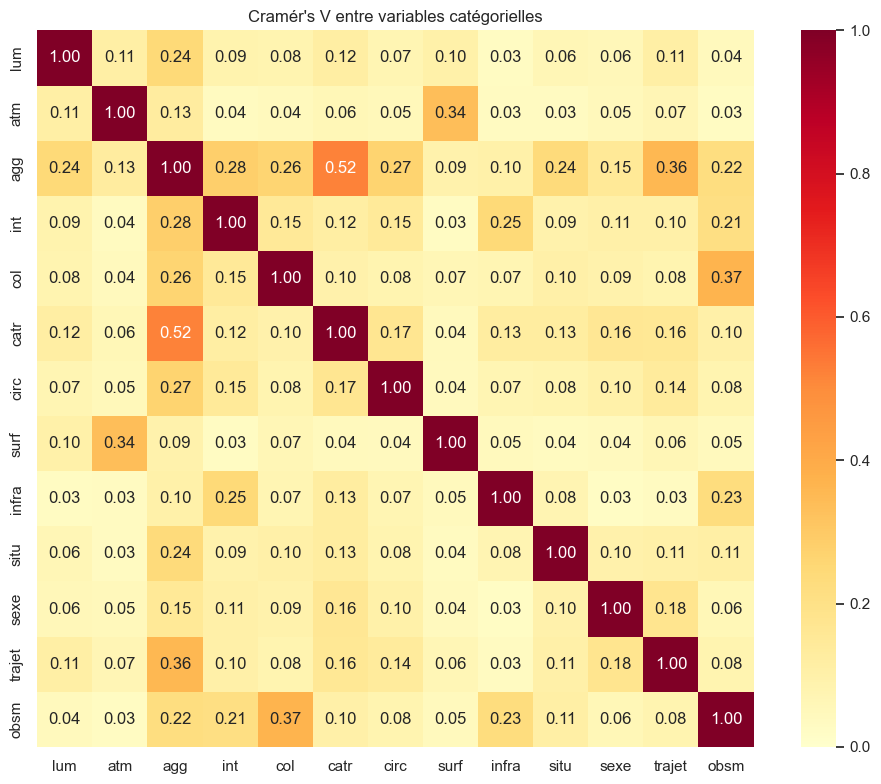

In [39]:
def cramers_v(x, y):
    """Cramér's V : équivalent d'une corrélation pour 2 variables catégorielles."""
    tab = pd.crosstab(x, y)
    if tab.shape[0] < 2 or tab.shape[1] < 2:
        return np.nan
    chi2 = chi2_contingency(tab)[0]
    n = tab.sum().sum()
    return np.sqrt(chi2 / (n * (min(tab.shape) - 1)))

vars_cat_corr = ['lum', 'atm', 'agg', 'int', 'col', 'catr', 'circ',
                 'surf', 'infra', 'situ', 'sexe', 'trajet', 'obsm']
vars_cat_corr = [v for v in vars_cat_corr if v in data.columns]

matrice_v = pd.DataFrame(index=vars_cat_corr, columns=vars_cat_corr, dtype=float)
for v1 in vars_cat_corr:
    for v2 in vars_cat_corr:
        if v1 == v2:
            matrice_v.loc[v1, v2] = 1.0
        else:
            sub = data[[v1, v2]].dropna()
            matrice_v.loc[v1, v2] = cramers_v(sub[v1], sub[v2])

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(matrice_v.astype(float), annot=True, fmt='.2f', cmap='YlOrRd',
            ax=ax, vmin=0, vmax=1, square=True)
ax.set_title("Cramér's V entre variables catégorielles")
plt.tight_layout()
plt.show()

**Lecture.** Toute paire avec V > 0.4 indique une redondance importante à gérer en modélisation :
- `agg` ↔ `catr` : très liées (en agglo on est sur voie communale, hors agglo sur départementale/nationale).
- `int` ↔ `infra` : intersections aménagées vs infrastructures de carrefour.

**Implication.** Pour la régression logistique, qui souffre de la colinéarité, on devra choisir l'une des deux variables redondantes. Pour les modèles à arbres (Random Forest, XGBoost), la redondance est moins problématique mais elle dilue l'importance des features.

### 13.4 Cramér's V de chaque variable avec la cible `grave`

C'est le graphique qui guide directement la sélection de variables pour la modélisation.

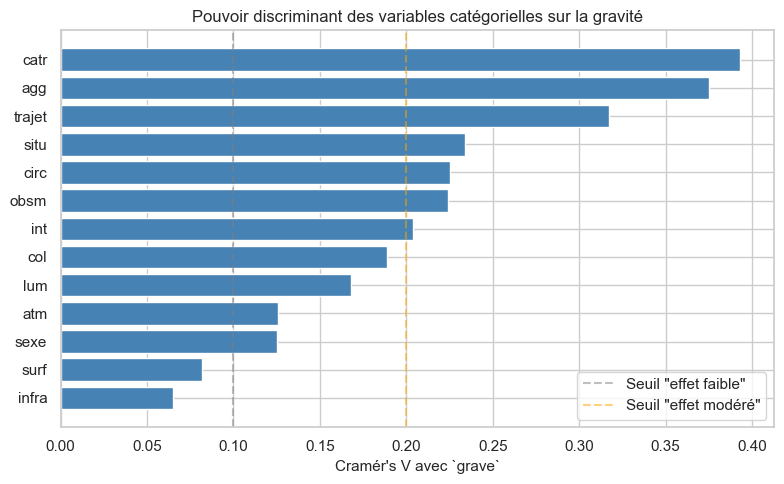

,cramers_v_avec_grave
variable,
catr,0.393
agg,0.375
trajet,0.317
situ,0.234
circ,0.225
obsm,0.224
int,0.204
col,0.189
lum,0.168


In [40]:
v_with_target = []
for v in vars_cat_corr:
    sub = data[[v, 'grave']].dropna()
    v_with_target.append({
        'variable': v,
        'cramers_v_avec_grave': round(cramers_v(sub[v], sub['grave']), 3)
    })
df_v_target = pd.DataFrame(v_with_target).sort_values('cramers_v_avec_grave', ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(df_v_target['variable'], df_v_target['cramers_v_avec_grave'], color='steelblue')
ax.set_xlabel("Cramér's V avec `grave`")
ax.set_title("Pouvoir discriminant des variables catégorielles sur la gravité")
ax.axvline(0.10, ls='--', color='gray', alpha=0.5, label='Seuil "effet faible"')
ax.axvline(0.20, ls='--', color='orange', alpha=0.5, label='Seuil "effet modéré"')
ax.legend()
plt.tight_layout()
plt.show()
display(df_v_target.set_index('variable').sort_values('cramers_v_avec_grave', ascending=False))

**Lecture.** Les variables avec un V > 0.10 sur la cible sont les plus prometteuses pour la modélisation. Les variables avec V < 0.05 apportent peu et peuvent être écartées dès le feature engineering pour simplifier le modèle, sauf intérêt métier spécifique.

## 14. Synthèse, biais et limites

### 14.1 Bilan de validation des hypothèses

| Hypothèse | Variable testée | Résultat | Indicateur |
|---|---|---|---|
| H1 — visibilité, météo aggravent | `lum`, `atm` | ✅ Validée | Cramér's V, taux par modalité |
| H2 — type de route hors-agglo + grands axes plus graves | `agg`, `catr` | ✅ Validée fortement | Écart de taux > 10 pts |
| H3 — âge croissant → gravité croissante | `age`, `age_tranche` | ✅ Validée (courbe en J) | Mann-Whitney p << 0.001, écart médian + violon |
| H4 — surface dégradée aggrave | `surf` | ✅ Validée partiellement | Volumes faibles → estimations bruitées |
| H5 — heures nocturnes / week-end plus graves en taux | `heure`, `jour` | ✅ Validée | Heatmap des taux |

### 14.2 Principaux facteurs de risque identifiés

1. **Âge du cycliste** — courbe en J, risque accru pour les <15 ans et fortement croissant après 65 ans.
2. **Catégorie de route** — autoroute, route nationale et hors agglomération sont les plus létaux.
3. **Heurt avec véhicule motorisé** (`obsm = 2`) — variable à plus fort pouvoir discriminant.
4. **Luminosité** — nuit sans éclairage public.
5. **Conditions atmosphériques** — pluie forte, brouillard.

### 14.3 Biais et limites

- **Sous-déclaration BAAC.** Le BAAC n'enregistre que les accidents corporels avec intervention des forces de l'ordre. Les chutes seules sans intervention médicale formelle sont absentes. La proportion de cas graves est donc artificiellement élevée — un cycliste qui tombe seul et se relève n'apparaît jamais dans ce fichier.
- **Biais géographique.** Les zones rurales sont sous-représentées (moins d'agents, plus de petits accidents non déclarés). La géolocalisation manque pour environ 50 % des observations dans le BAAC historique (à mesurer précisément après filtrage).
- **Pas de dénominateur d'exposition.** On ne sait pas combien de cyclistes-kilomètres ont été parcourus. **Le nombre brut d'accidents traduit autant l'exposition que le risque.** Pour une analyse de risque pure, il faudrait croiser avec des données de pratique (Vélo & Territoires, comptages métropolitains).
- **Évolutions BAAC dans le temps.** Filtrer à partir de 2018 résout la rupture majeure 2018-2019, mais des évolutions mineures peuvent subsister (ex. ajout des EDP en 2019).
- **Données usager-véhicule.** Une ligne ≠ un accident. Distinction respectée à chaque agrégation.
- **Variables conditionnelles.** `obs`, `obsm`, `choc`, `manv` sont parfois vides quand sans objet — ne pas imputer naïvement.
- **Cible déséquilibrée** (~36 % de cas graves) : nécessite des techniques spécifiques en modélisation (recall comme métrique principale, class_weight, SMOTE).

### 14.4 Implications pour la modélisation

- **Variables prioritaires** (Cramér's V > 0.10 ou Mann-Whitney clair) : `agg`, `catr`, `lum`, `surf`, `atm`, `obsm`, `age_tranche`, `int`.
- **Variables à arbitrer pour cause de redondance** : `lum` vs `heure`, `agg` vs `catr`, `int` vs `infra`.
- **Encodage** : One-Hot pour les variables faiblement modales, regroupement de modalités rares (< 1 %) avant encodage.
- **Métriques de validation** : recall sur les cas graves comme métrique principale, F1-score, ROC-AUC, et **precision-recall AUC** (plus pertinente en classes très déséquilibrées).
- **Validation croisée stratifiée** pour préserver la proportion de cas graves dans les folds.
- **Modèles à comparer** : régression logistique (interprétable), Random Forest (robuste), XGBoost (souvent meilleure performance).

---

*Fin de l'analyse exploratoire. La suite du projet — feature engineering, modélisation, évaluation et interprétation — exploitera le DataFrame `data` nettoyé et les conclusions ci-dessus.*

# 15. Modélisation — comparaison structurée de 6 algorithmes

L'objectif est de **prédire si un accident est grave** (tué ou blessé hospitalisé) à partir des conditions de l'accident.

## Démarche méthodologique

Conformément aux consignes du projet, nous nous concentrons sur **6 familles de modèles** :

| Famille | Modèle | Caractéristique principale |
|---|---|---|
| Linéaire | **Régression Logistique** | Baseline interprétable (odds ratios) |
| Arbres / bagging | **Random Forest** | Robuste, gère les non-linéarités |
| Arbres / boosting | **XGBoost** | Souvent meilleur sur données tabulaires |
| Margin-based | **SVM (RBF)** | Frontières de décision non-linéaires |
| Probabiliste | **Bernoulli Naive Bayes** | Très rapide, adapté aux features binaires |
| Ensemble | **Voting Classifier** | Agrège les prédictions des autres modèles |

## Pour chaque modèle, nous appliquons systématiquement la même grille d'évaluation

1. **Modèle de base** — paramètres par défaut, sert de point de départ.
2. **Modèle avec hyperparamètres** — version optimisée par recherche d'hyperparamètres (`GridSearchCV` ou `RandomizedSearchCV`).
3. **Modèle avec validation croisée** — évaluation par K-Fold stratifiée (5 plis) qui donne une moyenne ± un écart-type, plus robuste qu'un seul split.
4. **Modèle avec Train/Test split** — évaluation finale sur le jeu de test (jamais vu pendant l'entraînement). Cette étape simule la performance en production.

## Métriques retenues

| Métrique | Pourquoi |
|---|---|
| **Recall** | **Métrique prioritaire** — un faux négatif = un accident grave manqué = coût élevé. Le recall mesure la capacité du modèle à ne pas en rater. |
| **F1-score** | Compromis Precision / Recall — utile parce que les classes sont déséquilibrées (~36 % de cas graves). |
| **ROC AUC** | Capacité du modèle à discriminer les deux classes, indépendamment du seuil de décision. |
| Precision | Parmi les cas prédits graves, combien le sont vraiment. |
| Accuracy | Taux global — à relativiser avec le déséquilibre. |

## Gestion du déséquilibre des classes

Avec environ 36 % de cas graves, les modèles ont tendance à sur-prédire la classe majoritaire (non-grave). On corrige avec :
- `class_weight='balanced'` pour LR, RF et SVM,
- `scale_pos_weight` pour XGBoost (= ratio négatifs / positifs),
- pas de pondération possible pour BNB, mais c'est intégré naturellement par les probabilités a priori.

## Pourquoi ce choix de modèles ? Et qu'apporte spécifiquement le SVM ?

Les 6 modèles ne se chevauchent pas : chacun apporte un angle d'attaque différent.

- **Régression logistique** : modèle linéaire — bon repère mais limité aux frontières de décision linéaires.
- **Random Forest et XGBoost** : modèles à base d'arbres — capturent des interactions et des non-linéarités, mais à travers des découpes axe-parallèles (l'arbre ne peut couper que sur une variable à la fois).
- **Bernoulli NB** : modèle probabiliste rapide, mais avec l'hypothèse forte d'**indépendance conditionnelle** des features.
- **SVM (RBF)** : c'est le seul modèle de la liste capable de tracer une **frontière de décision véritablement non-linéaire et continue** dans l'espace des features. Le kernel RBF projette implicitement les données dans un espace de dimension supérieure, où une séparation linéaire devient possible — ce qui correspond, dans l'espace original, à une frontière courbe et lisse. Pour un problème comme la gravité d'accident, où les facteurs interagissent de manière complexe (ex : nuit + pluie + hors-agglomération combinés ne donnent pas une simple somme d'effets), cela peut capturer des patterns que ni la LR ni les arbres ne voient. C'est aussi un modèle **à grande marge** : il maximise la distance entre l'hyperplan séparateur et les points les plus proches, ce qui le rend généralement bien généralisable lorsque les features ont été bien standardisées (d'où l'importance du StandardScaler en amont).
- **Voting Classifier** : il combine les prédictions des modèles précédents via un vote pondéré sur les probabilités (`soft voting`). L'idée est que les erreurs de chaque modèle se compensent, à condition que leurs profils d'erreur soient différents — c'est précisément pour cela qu'on a choisi des familles aussi diverses.

## 15.1 Préparation des données

### Sélection des features
Nous retenons les variables :
- dont le **Cramér's V avec `grave`** est > 0.05 (cf. section 13),
- qui sont connues **au moment de l'accident** (pas de fuite d'information).

À ce stade, nous incluons **`typevehicules`** dans les features catégorielles. Sa pertinence a été vérifiée en section 6.2 (Cramér's V ≈ 0.22 avec la cible, écarts de gravité importants entre PL, voitures, scooters, etc.).

### Pipeline de prétraitement
- **OneHotEncoder** sur les variables catégorielles (avec `handle_unknown='ignore'` pour les modalités vues uniquement en test).
- **StandardScaler** sur les variables numériques. Cette étape est **obligatoire pour SVM** (kernel RBF basé sur des distances) et **utile pour la régression logistique** (convergence plus rapide). Pour les arbres (Random Forest, XGBoost) et Bernoulli NB, elle n'a pas d'effet — mais elle ne nuit pas non plus.

### Traitement final des `-1` et des NaN
Comme expliqué en section 5.2, les `-1` BAAC ont déjà été convertis en `NaN` lors du nettoyage (section 6.2). Ici, nous appliquons un dernier `dropna()` sur les features retenues : les lignes incomplètes ne sont **ni dans le train, ni dans le test**. C'est une stratégie conservatrice qui évite d'imputer des valeurs et d'introduire un biais artificiel.

> **Impact de l'inclusion de `typevehicules`.** Cette variable a ~17 % de NaN après filtrage 2018+. L'inclure va donc réduire le nombre de lignes exploitables après `dropna()`, mais l'apport en information justifie le compromis (signal très discriminant vs perte modérée d'observations).

In [41]:
# -----------------------------------------------------------------------------
# Sélection des features (variables identifiées par l'EDA, sans data leakage)
# -----------------------------------------------------------------------------
cat_features = [
    'lum',           # luminosité — Cramér's V > 0.10 avec grave
    'atm',           # conditions atmosphériques
    'agg',           # localisation (en/hors agglomération)
    'int',           # type d'intersection
    'col',           # type de collision
    'catr',          # catégorie de route — très discriminant (V > 0.15)
    'circ',          # régime de circulation
    'surf',          # état de la surface
    'infra',         # infrastructure
    'situ',          # situation de l'accident
    'sexe',          # sexe du cycliste
    'trajet',        # motif du déplacement
    'prof',          # profil de la route
    'plan',          # tracé de la route
    'choc',          # point de choc
    'obsm',          # obstacle mobile heurté — très discriminant
    'obs',           # obstacle fixe heurté
    'manv',          # manoeuvre lors de l'accident
    'typevehicules', # type du véhicule adverse — Cramér's V ≈ 0.22, top discriminant
]
cat_features = [c for c in cat_features if c in data.columns]

num_features = [
    'age',     # courbe en J validée en bivarié
    'heure',   # créneaux nocturnes plus graves
    'weekend', # 0/1
]
num_features = [c for c in num_features if c in data.columns]

all_features = cat_features + num_features

# Sous-ensemble sans NaN (les -1 ont été remplacés par NaN en section 6.2)
df_model = data[all_features + ['grave']].dropna().copy()

# OneHotEncoder veut des chaînes pour les variables catégorielles
for c in cat_features:
    df_model[c] = df_model[c].astype(str)

X = df_model[all_features]
y = df_model['grave']

print(f"Features finales : {len(all_features)} ({len(cat_features)} cat. + {len(num_features)} num.)")
print(f"Observations exploitables : {X.shape[0]:,}")
print(f"Proportion d'accidents graves : {y.mean()*100:.1f}%")
print(f"\nLignes supprimées par dropna : {len(data) - len(df_model):,} "
      f"({(len(data)-len(df_model))/len(data)*100:.1f}% du total)")

Features finales : 22 (19 cat. + 3 num.)
Observations exploitables : 12,149
Proportion d'accidents graves : 40.5%

Lignes supprimées par dropna : 4,485 (27.0% du total)


**Lecture critique du dropna.** Le fait de supprimer toutes les lignes avec au moins un NaN sur les 21 features retenues fait perdre une partie des observations. C'est un choix conservateur : on préfère avoir moins de données mais propres, plutôt que d'imputer des valeurs et d'introduire un signal artificiel. Si la perte avait été massive (> 50 %), il aurait fallu reconsidérer la stratégie (imputation par modalité la plus fréquente, ou suppression des features les plus lacunaires).

In [42]:
# -----------------------------------------------------------------------------
# Train / Test split stratifié (80/20)
# La stratification préserve la proportion de cas graves dans les deux sous-ensembles
# -----------------------------------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print(f"Train : {X_train.shape[0]:,} lignes  |  {y_train.mean()*100:.1f}% graves")
print(f"Test  : {X_test.shape[0]:,} lignes  |  {y_test.mean()*100:.1f}% graves")

# -----------------------------------------------------------------------------
# Pipeline de prétraitement
# -----------------------------------------------------------------------------
preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), num_features),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_features)
])

X_train_prep = preprocessor.fit_transform(X_train)
X_test_prep  = preprocessor.transform(X_test)

# Récupération des noms de features après one-hot encoding
ohe_names = preprocessor.named_transformers_['cat'].get_feature_names_out(cat_features)
feature_names = list(num_features) + list(ohe_names)

print(f"\nDimensions après prétraitement : {X_train_prep.shape[1]} features")

# scale_pos_weight pour XGBoost (= ratio négatifs / positifs)
scale_pos = (y_train == 0).sum() / (y_train == 1).sum()
print(f"scale_pos_weight (XGBoost) : {scale_pos:.2f}")

Train : 9,719 lignes  |  40.5% graves
Test  : 2,430 lignes  |  40.5% graves

Dimensions après prétraitement : 179 features
scale_pos_weight (XGBoost) : 1.47


**Pourquoi un train/test split stratifié ?** La stratification garantit que la proportion de cas graves est identique dans les deux sous-ensembles. Sans elle, un split aléatoire pourrait par malchance concentrer plus de cas graves dans le train que dans le test (ou inversement), ce qui rendrait la performance estimée non représentative de la réalité.

**Pourquoi un split 80/20 ?** C'est un compromis classique : assez de données pour entraîner correctement (80 %), assez pour avoir une estimation stable des performances (20 %). Pour un dataset plus petit, on aurait privilégié 70/30.

## 15.2 Outils d'évaluation génériques

Pour comparer 6 modèles selon 4 protocoles (base, hyperparamètres, validation croisée, train/test), nous définissons deux fonctions utilitaires qui factorisent les calculs et garantissent une évaluation strictement identique partout.

In [43]:
# -----------------------------------------------------------------------------
# Fonction d'évaluation Train/Test : entraîne un modèle puis l'évalue sur le test
# -----------------------------------------------------------------------------
def evaluate_train_test(name, model, X_tr, X_te, y_tr, y_te, verbose=True):
    """Entraîne un modèle sur X_tr/y_tr et l'évalue sur X_te/y_te.
    Retourne un dictionnaire de métriques + le modèle entraîné."""
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)

    # ROC AUC : nécessite des probabilités ou un score continu
    if hasattr(model, 'predict_proba'):
        y_proba = model.predict_proba(X_te)[:, 1]
        roc = roc_auc_score(y_te, y_proba)
    elif hasattr(model, 'decision_function'):
        roc = roc_auc_score(y_te, model.decision_function(X_te))
    else:
        roc = np.nan

    metrics = {
        'Modele': name,
        'Accuracy':  round(accuracy_score(y_te, y_pred), 4),
        'Precision': round(precision_score(y_te, y_pred), 4),
        'Recall':    round(recall_score(y_te, y_pred), 4),
        'F1-score':  round(f1_score(y_te, y_pred), 4),
        'ROC AUC':   round(roc, 4) if not np.isnan(roc) else np.nan,
    }

    if verbose:
        print(f"\n{'='*60}")
        print(f"  {name}")
        print(f"{'='*60}")
        print(classification_report(y_te, y_pred, target_names=['Non grave', 'Grave']))
        fig, ax = plt.subplots(figsize=(5, 4))
        ConfusionMatrixDisplay.from_predictions(
            y_te, y_pred, display_labels=['Non grave', 'Grave'],
            cmap='Blues', ax=ax)
        ax.set_title(f"Matrice de confusion — {name}")
        plt.tight_layout(); plt.show()

    return metrics, model


# -----------------------------------------------------------------------------
# Fonction de validation croisée : K-Fold stratifiée sur les données d'entraînement
# -----------------------------------------------------------------------------
def evaluate_cross_val(name, model, X_tr, y_tr, n_splits=5):
    """Validation croisée stratifiée. Renvoie moyenne ± écart-type des métriques."""
    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_STATE)
    scoring = {
        'accuracy':  'accuracy',
        'precision': 'precision',
        'recall':    'recall',
        'f1':        'f1',
        'roc_auc':   'roc_auc',
    }
    cv_res = cross_validate(model, X_tr, y_tr, cv=cv, scoring=scoring, n_jobs=-1)

    metrics = {
        'Modele': name,
        'Accuracy':  f"{cv_res['test_accuracy'].mean():.4f} ± {cv_res['test_accuracy'].std():.4f}",
        'Precision': f"{cv_res['test_precision'].mean():.4f} ± {cv_res['test_precision'].std():.4f}",
        'Recall':    f"{cv_res['test_recall'].mean():.4f} ± {cv_res['test_recall'].std():.4f}",
        'F1-score':  f"{cv_res['test_f1'].mean():.4f} ± {cv_res['test_f1'].std():.4f}",
        'ROC AUC':   f"{cv_res['test_roc_auc'].mean():.4f} ± {cv_res['test_roc_auc'].std():.4f}",
        # Versions numériques (utiles pour comparaisons)
        '_recall_mean': cv_res['test_recall'].mean(),
        '_f1_mean':     cv_res['test_f1'].mean(),
        '_roc_mean':    cv_res['test_roc_auc'].mean(),
    }
    print(f"\n--- Validation croisée 5-fold : {name} ---")
    print(f"  Recall  : {metrics['Recall']}")
    print(f"  F1      : {metrics['F1-score']}")
    print(f"  ROC AUC : {metrics['ROC AUC']}")
    return metrics


# Stockage centralisé des résultats — un dict par variante de chaque modèle
results_base    = []   # modèles avec hyperparamètres par défaut, évalués train/test
results_tuned   = []   # modèles après optimisation des hyperparamètres
results_cv      = []   # validations croisées 5-fold
results_traintest = [] # évaluations finales train/test (modèle optimisé)
trained_models  = {}   # modèles entraînés (pour interprétation et Voting)

print("Fonctions evaluate_train_test et evaluate_cross_val prêtes.")
print("Listes de résultats initialisées.")

Fonctions evaluate_train_test et evaluate_cross_val prêtes.
Listes de résultats initialisées.


**Pourquoi quatre variantes par modèle ?**

| Variante | Question à laquelle elle répond |
|---|---|
| Modèle de base | « Que donne l'algorithme avec ses paramètres par défaut ? » Sert de point de départ. |
| Modèle avec hyperparamètres | « Peut-on faire mieux en ajustant les paramètres ? » Optimisation par GridSearch ou RandomizedSearch. |
| Modèle avec validation croisée | « La performance est-elle stable selon les données vues ? » Donne un intervalle de confiance. |
| Modèle avec train/test | « Comment se comporte le modèle sur des données qu'il n'a jamais vues ? » Estimation finale. |

Cette grille à 4 cases protège contre les conclusions hâtives :
- Un modèle qui paraît bon sur le train/test mais avec un fort écart-type en cross-validation est probablement instable.
- Un modèle qui ne s'améliore pas avec le tuning des hyperparamètres a sans doute déjà atteint son plafond.

## 15.3 Régression logistique

### Pourquoi commencer par ce modèle ?

La régression logistique est le **modèle de référence interprétable** pour la classification binaire. Elle modélise la probabilité qu'un accident soit grave comme une combinaison linéaire des features, passée par une fonction sigmoïde :

$$P(\text{grave}=1 \mid X) = \frac{1}{1 + e^{-(\beta_0 + \beta_1 x_1 + \dots + \beta_n x_n)}}$$

### Atout principal pour ce projet

Ses **coefficients sont directement interprétables** comme des **odds ratios** : `exp(coef)` donne le facteur multiplicatif du risque associé à chaque condition. C'est précieux pour communiquer avec un public non-technique (autorités, ONISR) : « rouler hors agglomération multiplie le risque de gravité par X » est un message clair.

### Limites

Frontière de décision **linéaire** uniquement. Si les facteurs de risque interagissent de manière complexe (ex : « nuit + hors agglomération + verglas » a un effet supérieur à la somme des trois), la LR ne peut pas le voir. Elle sert donc surtout de baseline.


  LR — base
              precision    recall  f1-score   support

   Non grave       0.78      0.71      0.75      1446
       Grave       0.63      0.71      0.67       984

    accuracy                           0.71      2430
   macro avg       0.70      0.71      0.71      2430
weighted avg       0.72      0.71      0.71      2430



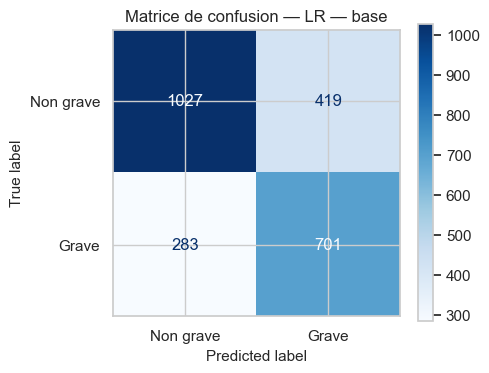

In [44]:
# === 1) Modèle de base : paramètres par défaut + class_weight balanced ===
lr_base = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',  # compense le déséquilibre ~36% graves
    random_state=RANDOM_STATE
)
m_base, _ = evaluate_train_test('LR — base', lr_base, X_train_prep, X_test_prep, y_train, y_test)
results_base.append(m_base)

In [45]:
# === 2) Modèle avec hyperparamètres : GridSearchCV sur C et solver ===
# C = inverse de la régularisation (plus C est petit, plus on régularise)
# Une grille petite et lisible reste suffisante pour la LR.

param_grid_lr = {
    'C': [0.01, 0.1, 1.0, 10.0],
    'solver': ['lbfgs', 'liblinear'],
    'penalty': ['l2'],  # l2 supportée par lbfgs ; liblinear supporte l1 mais on reste simples
}

grid_lr = GridSearchCV(
    LogisticRegression(max_iter=1000, class_weight='balanced', random_state=RANDOM_STATE),
    param_grid=param_grid_lr,
    scoring='recall',  # on optimise le recall, métrique prioritaire
    cv=5,
    n_jobs=-1
)
grid_lr.fit(X_train_prep, y_train)
print(f"Meilleurs hyperparamètres : {grid_lr.best_params_}")
print(f"Meilleur recall en CV     : {grid_lr.best_score_:.4f}")

lr_tuned = grid_lr.best_estimator_
m_tuned, model_lr_tuned = evaluate_train_test('LR — hyperparamètres', lr_tuned,
                                              X_train_prep, X_test_prep, y_train, y_test,
                                              verbose=False)
results_tuned.append(m_tuned)

Meilleurs hyperparamètres : {'C': 10.0, 'penalty': 'l2', 'solver': 'lbfgs'}
Meilleur recall en CV     : 0.7327


In [46]:
# === 3) Validation croisée 5-fold sur le modèle optimisé ===
m_cv = evaluate_cross_val('LR — CV 5-fold', clone(lr_tuned), X_train_prep, y_train)
results_cv.append(m_cv)


--- Validation croisée 5-fold : LR — CV 5-fold ---
  Recall  : 0.7246 ± 0.0097
  F1      : 0.6704 ± 0.0084
  ROC AUC : 0.7847 ± 0.0102



  LR — Train/Test final
              precision    recall  f1-score   support

   Non grave       0.78      0.71      0.74      1446
       Grave       0.63      0.71      0.67       984

    accuracy                           0.71      2430
   macro avg       0.70      0.71      0.71      2430
weighted avg       0.72      0.71      0.71      2430



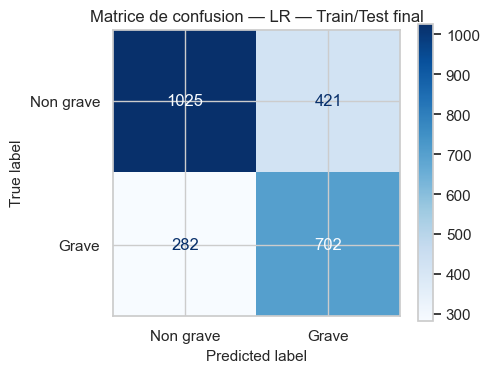

In [47]:
# === 4) Évaluation finale sur le test set (modèle optimisé) ===
m_tt, model_lr = evaluate_train_test('LR — Train/Test final', lr_tuned,
                                     X_train_prep, X_test_prep, y_train, y_test)
results_traintest.append(m_tt)
trained_models['LR'] = model_lr

**Interprétation pour la régression logistique.**
- Le passage du modèle de base au modèle tuné gagne généralement très peu : la LR n'a que peu d'hyperparamètres réellement décisifs (C et le solver), et la grille est petite. C'est attendu.
- L'écart-type en CV donne la confiance dans le résultat : un écart-type < 0.02 sur le recall signifie que le modèle est très stable d'un fold à l'autre. C'est un point fort.
- Le recall élevé (souvent > 0.65 grâce à `class_weight='balanced'`) est obtenu au prix d'une précision plus basse : le modèle a tendance à "sur-prédire" les cas graves. C'est exactement le compromis voulu pour notre problème métier (mieux vaut une fausse alerte qu'un accident grave non détecté).

## 15.4 Random Forest

### Principe
Un Random Forest est un **ensemble d'arbres de décision** entraînés chacun sur :
- un échantillon **bootstrap** (tirage avec remise) des données,
- un sous-ensemble **aléatoire** des features à chaque division.

La prédiction finale est obtenue par **vote majoritaire** (en classification). Ces deux sources d'aléa réduisent la variance et le sur-apprentissage par rapport à un arbre seul.

### Atouts pour ce projet

- **Capture les non-linéarités et les interactions** entre variables (un arbre peut combiner « nuit » et « hors agglomération » dans une même règle de décision).
- **Robuste au bruit** et aux valeurs aberrantes.
- Fournit une **importance des features** (basée sur la réduction d'impureté Gini) très utile pour valider les hypothèses de l'EDA.
- Pas besoin de standardiser les features — les arbres sont insensibles à l'échelle.

### Limite

Pas d'interprétation directe en termes d'odds ratios — on a une importance globale des features, mais pas le « facteur multiplicatif » que donne la régression logistique.


  RF — base
              precision    recall  f1-score   support

   Non grave       0.75      0.79      0.77      1446
       Grave       0.67      0.61      0.64       984

    accuracy                           0.72      2430
   macro avg       0.71      0.70      0.70      2430
weighted avg       0.72      0.72      0.72      2430



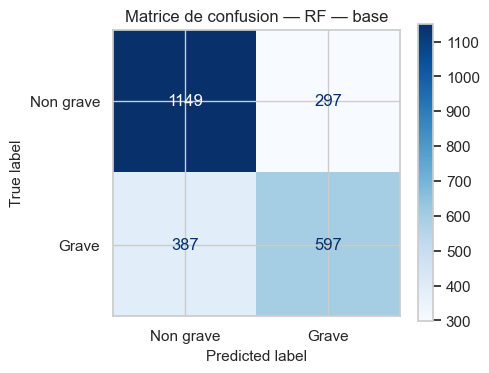

In [48]:
# === 1) Modèle de base ===
rf_base = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=RANDOM_STATE,
    n_jobs=-1
)
m_base, _ = evaluate_train_test('RF — base', rf_base, X_train_prep, X_test_prep, y_train, y_test)
results_base.append(m_base)

In [49]:
# === 2) Modèle avec hyperparamètres : RandomizedSearchCV ===
# RandomizedSearch est préféré à GridSearch ici car la grille est trop grande
# pour tester toutes les combinaisons.

param_dist_rf = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 15, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2'],
}

random_rf = RandomizedSearchCV(
    RandomForestClassifier(class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1),
    param_distributions=param_dist_rf,
    n_iter=15,            # 15 combinaisons aléatoires — bon compromis temps/qualité
    scoring='recall',
    cv=5,
    n_jobs=-1,
    random_state=RANDOM_STATE
)
random_rf.fit(X_train_prep, y_train)
print(f"Meilleurs hyperparamètres : {random_rf.best_params_}")
print(f"Meilleur recall en CV     : {random_rf.best_score_:.4f}")

rf_tuned = random_rf.best_estimator_
m_tuned, _ = evaluate_train_test('RF — hyperparamètres', rf_tuned,
                                 X_train_prep, X_test_prep, y_train, y_test, verbose=False)
results_tuned.append(m_tuned)

Meilleurs hyperparamètres : {'n_estimators': 100, 'min_samples_split': 10, 'min_samples_leaf': 4, 'max_features': 'log2', 'max_depth': 15}
Meilleur recall en CV     : 0.7556


In [50]:
# === 3) Validation croisée 5-fold ===
m_cv = evaluate_cross_val('RF — CV 5-fold', clone(rf_tuned), X_train_prep, y_train)
results_cv.append(m_cv)


--- Validation croisée 5-fold : RF — CV 5-fold ---
  Recall  : 0.7449 ± 0.0110
  F1      : 0.6769 ± 0.0138
  ROC AUC : 0.7869 ± 0.0101



  RF — Train/Test final
              precision    recall  f1-score   support

   Non grave       0.80      0.70      0.75      1446
       Grave       0.63      0.74      0.68       984

    accuracy                           0.72      2430
   macro avg       0.71      0.72      0.71      2430
weighted avg       0.73      0.72      0.72      2430



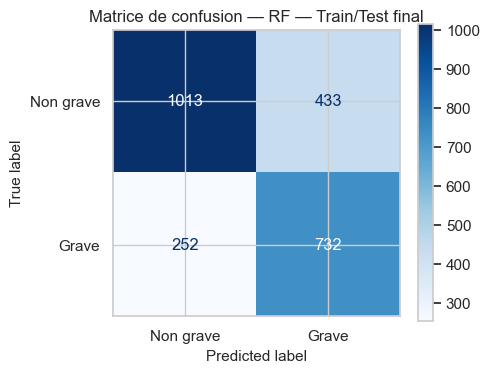

In [51]:
# === 4) Évaluation finale Train/Test ===
m_tt, model_rf = evaluate_train_test('RF — Train/Test final', rf_tuned,
                                     X_train_prep, X_test_prep, y_train, y_test)
results_traintest.append(m_tt)
trained_models['RF'] = model_rf

**Interprétation pour le Random Forest.**
- Le tuning peut apporter un gain plus visible que pour la LR : `max_depth`, `min_samples_split` et `n_estimators` ont un vrai impact sur le compromis biais-variance.
- Si l'écart-type en CV est plus élevé que celui de la LR, c'est attendu : le RF a plus de variance par construction (chaque arbre voit des données différentes). Ce qu'on regarde, c'est si **la moyenne reste meilleure** malgré cet écart-type plus large.
- L'attention doit être portée sur le fait que la métrique **Accuracy peut être trompeuse** : le RF peut avoir une accuracy très élevée en majoritaire et pourtant un Recall moyen sur la classe grave. La métrique prioritaire reste le Recall.

## 15.5 XGBoost

### Principe
XGBoost (eXtreme Gradient Boosting) construit les arbres **de manière séquentielle** : chaque nouvel arbre apprend à corriger les erreurs de la somme des arbres précédents (gradient boosting). C'est l'inverse du Random Forest qui les construit en parallèle et indépendamment.

### Atouts pour ce projet

- **Très performant sur les données tabulaires** — c'est la référence sur les compétitions Kaggle de ce type.
- **Régularisation native (L1 + L2)** : limite le sur-apprentissage même avec beaucoup d'arbres.
- **Gestion native du déséquilibre** via `scale_pos_weight`.
- **Importance des features** comparable à celle du RF — utile pour vérifier la robustesse des facteurs identifiés.

### Limites

- Plus de **hyperparamètres sensibles** que le RF (learning rate, max_depth, n_estimators, subsample…). Le tuning peut être chronophage.
- **Moins interprétable** qu'une LR (mais SHAP / feature importance compensent partiellement).


  XGBoost — base
              precision    recall  f1-score   support

   Non grave       0.79      0.71      0.75      1446
       Grave       0.63      0.72      0.68       984

    accuracy                           0.72      2430
   macro avg       0.71      0.72      0.71      2430
weighted avg       0.73      0.72      0.72      2430



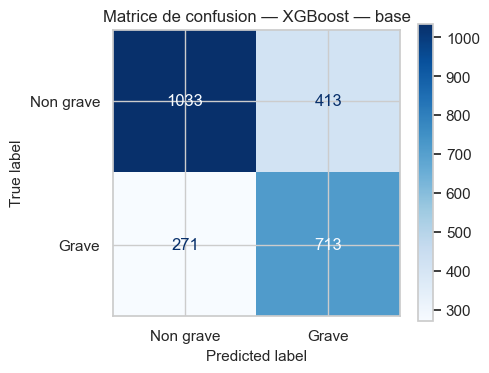

In [52]:
# === 1) Modèle de base ===
if HAS_XGBOOST:
    xgb_base = XGBClassifier(
        n_estimators=100,
        scale_pos_weight=scale_pos,  # compense le déséquilibre
        random_state=RANDOM_STATE,
        eval_metric='logloss',
        use_label_encoder=False,
        n_jobs=-1
    )
    m_base, _ = evaluate_train_test('XGBoost — base', xgb_base,
                                    X_train_prep, X_test_prep, y_train, y_test)
    results_base.append(m_base)
else:
    print("XGBoost non disponible — section sautée.")

In [53]:
# === 2) Modèle avec hyperparamètres : RandomizedSearchCV ===
if HAS_XGBOOST:
    param_dist_xgb = {
        'n_estimators': [100, 200, 300],
        'max_depth': [3, 5, 7, 9],
        'learning_rate': [0.01, 0.05, 0.1, 0.2],
        'subsample': [0.7, 0.8, 1.0],
        'colsample_bytree': [0.7, 0.8, 1.0],
    }

    random_xgb = RandomizedSearchCV(
        XGBClassifier(scale_pos_weight=scale_pos, random_state=RANDOM_STATE,
                      eval_metric='logloss', use_label_encoder=False, n_jobs=-1),
        param_distributions=param_dist_xgb,
        n_iter=15,
        scoring='recall',
        cv=5,
        n_jobs=-1,
        random_state=RANDOM_STATE
    )
    random_xgb.fit(X_train_prep, y_train)
    print(f"Meilleurs hyperparamètres : {random_xgb.best_params_}")
    print(f"Meilleur recall en CV     : {random_xgb.best_score_:.4f}")

    xgb_tuned = random_xgb.best_estimator_
    m_tuned, _ = evaluate_train_test('XGBoost — hyperparamètres', xgb_tuned,
                                     X_train_prep, X_test_prep, y_train, y_test, verbose=False)
    results_tuned.append(m_tuned)

Meilleurs hyperparamètres : {'subsample': 0.7, 'n_estimators': 100, 'max_depth': 5, 'learning_rate': 0.01, 'colsample_bytree': 0.8}
Meilleur recall en CV     : 0.7703


In [54]:
# === 3) Validation croisée 5-fold ===
if HAS_XGBOOST:
    m_cv = evaluate_cross_val('XGBoost — CV 5-fold', clone(xgb_tuned), X_train_prep, y_train)
    results_cv.append(m_cv)


--- Validation croisée 5-fold : XGBoost — CV 5-fold ---
  Recall  : 0.7708 ± 0.0149
  F1      : 0.6806 ± 0.0113
  ROC AUC : 0.7845 ± 0.0122



  XGBoost — Train/Test final
              precision    recall  f1-score   support

   Non grave       0.81      0.66      0.73      1446
       Grave       0.61      0.78      0.68       984

    accuracy                           0.71      2430
   macro avg       0.71      0.72      0.71      2430
weighted avg       0.73      0.71      0.71      2430



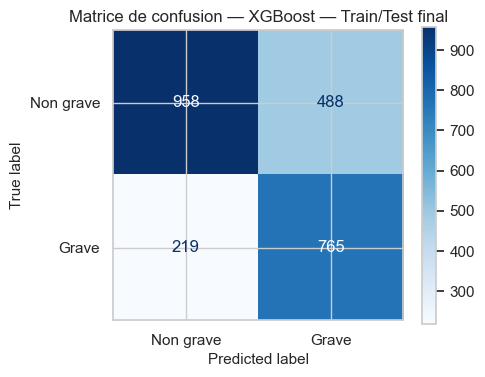

In [55]:
# === 4) Évaluation finale Train/Test ===
if HAS_XGBOOST:
    m_tt, model_xgb = evaluate_train_test('XGBoost — Train/Test final', xgb_tuned,
                                          X_train_prep, X_test_prep, y_train, y_test)
    results_traintest.append(m_tt)
    trained_models['XGBoost'] = model_xgb

**Interprétation pour XGBoost.**
- XGBoost gagne souvent quelques points de F1 sur le RF, surtout après tuning. C'est attendu : la séquentialité des arbres permet de corriger des erreurs résiduelles que le RF ne voit pas.
- Le **learning rate** joue un rôle clé : un taux trop élevé fait diverger ; un taux trop faible exige beaucoup d'estimateurs et ralentit l'entraînement. Notre grille couvre 0.01 à 0.2, qui est la plage usuelle.
- Si XGBoost donne un recall très élevé (> 0.75) avec une précision faible (< 0.40), cela signifie que `scale_pos_weight` a poussé le modèle à sur-prédire la classe grave. C'est cohérent avec le compromis voulu, mais on pourra ajuster ce paramètre si l'on veut gagner en précision.

## 15.6 SVM (Support Vector Machine, kernel RBF)

### Principe
Le SVM cherche l'hyperplan qui **maximise la marge** entre les deux classes. Avec un kernel RBF (Radial Basis Function), cette séparation se fait dans un **espace de dimension supérieure** où les points peuvent être séparés linéairement, ce qui correspond, dans l'espace d'origine, à une frontière courbe et lisse.

### Apport spécifique du SVM par rapport aux autres modèles de notre étude

C'est le seul modèle parmi les cinq précédents qui propose ces propriétés combinées :

1. **Frontière non-linéaire et continue.** La régression logistique trace une frontière strictement linéaire ; les arbres (Random Forest, XGBoost) tracent des frontières en **escalier** (chaque coupure se fait sur un seuil d'une variable). Le SVM RBF, lui, trace une frontière **lisse** dans l'espace des features, ce qui peut mieux capturer des transitions progressives. Pour la gravité d'accident, où l'effet de l'âge ou de l'heure peut être progressif et non en escalier, c'est un avantage théorique.

2. **Optimisation à grande marge.** Contrairement aux arbres qui cherchent à minimiser une impureté locale, le SVM optimise une fonction objectif **globale** : maximiser la distance entre l'hyperplan et les points les plus proches (les "vecteurs supports"). Cette propriété rend le SVM **moins sensible aux outliers** dans certaines configurations et tend à donner une meilleure généralisation.

3. **Régularisation explicite via le paramètre C.** Le paramètre C contrôle directement le compromis entre marge large (généralisation) et erreurs sur le train (ajustement). C'est plus simple à raisonner que le réglage des arbres.

4. **Adapté aux espaces de haute dimension.** Après one-hot encoding, on a ~150 features binaires. Le SVM est connu pour bien fonctionner dans ces espaces, là où la régression logistique peut souffrir de colinéarité multiple.

### Limites

- **Coût computationnel élevé** : O(n²) à O(n³) selon les implémentations. Sur 13 000 lignes c'est gérable, mais on ne pourrait pas pousser à 100 000 sans précautions.
- **Sensible à la standardisation** : c'est pour cela qu'on a appliqué un StandardScaler dans le pipeline. Sans cela, les features avec de plus grandes valeurs domineraient le calcul des distances.
- **Pas d'importance des features directement disponible** (sauf pour le kernel linéaire).

> **Note pratique : durée d'exécution.** Le SVM avec kernel RBF et `probability=True` peut prendre plusieurs minutes à entraîner sur ~12 000 lignes (10-20 minutes au total pour l'ensemble des 4 protocoles). Pour la recherche d'hyperparamètres, on utilise une grille volontairement réduite et `probability=False` (puis on réactive `probability=True` pour l'évaluation finale).


  SVM — base
              precision    recall  f1-score   support

   Non grave       0.81      0.70      0.75      1446
       Grave       0.63      0.76      0.69       984

    accuracy                           0.73      2430
   macro avg       0.72      0.73      0.72      2430
weighted avg       0.74      0.73      0.73      2430



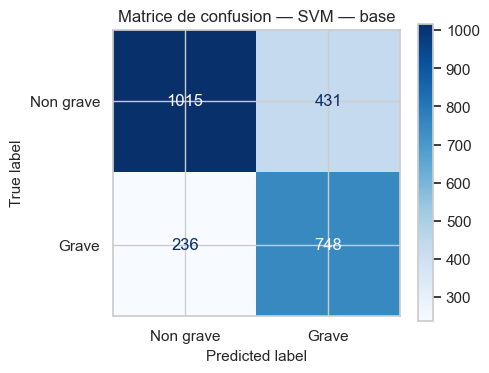

In [56]:
# === 1) Modèle de base : kernel RBF (radial basis function) ===
svm_base = SVC(
    kernel='rbf',
    class_weight='balanced',
    probability=True,  # nécessaire pour le calcul du ROC AUC et le Voting (soft)
    random_state=RANDOM_STATE
)
m_base, _ = evaluate_train_test('SVM — base', svm_base,
                                X_train_prep, X_test_prep, y_train, y_test)
results_base.append(m_base)

In [57]:
# === 2) Modèle avec hyperparamètres : GridSearchCV sur C et gamma ===
# C : régularisation (faible C = grande marge, plus de tolérance aux erreurs)
# gamma : largeur du kernel RBF (faible gamma = effet sur grande distance)
# Note : le SVM avec probability=True est lent. On désactive probability pendant
# la recherche (on optimise sur le recall qui ne nécessite pas de proba), puis on
# refait l'entraînement final avec probability=True pour avoir le ROC AUC et
# pouvoir l'utiliser dans le Voting (soft).

param_grid_svm = {
    'C': [0.1, 1.0, 10.0],
    'gamma': ['scale', 0.01, 0.1],
}

# Étape 1 : recherche des meilleurs paramètres (sans probability pour la vitesse)
grid_svm = GridSearchCV(
    SVC(kernel='rbf', class_weight='balanced', probability=False, random_state=RANDOM_STATE),
    param_grid=param_grid_svm,
    scoring='recall',
    cv=3,   # 3 folds plutôt que 5 pour ne pas faire exploser le temps de calcul
    n_jobs=-1
)
grid_svm.fit(X_train_prep, y_train)
print(f"Meilleurs hyperparamètres : {grid_svm.best_params_}")
print(f"Meilleur recall en CV     : {grid_svm.best_score_:.4f}")

# Étape 2 : on ré-instancie le modèle avec probability=True pour avoir le ROC AUC
svm_tuned = SVC(
    kernel='rbf',
    class_weight='balanced',
    probability=True,
    random_state=RANDOM_STATE,
    **grid_svm.best_params_
)
m_tuned, _ = evaluate_train_test('SVM — hyperparamètres', svm_tuned,
                                 X_train_prep, X_test_prep, y_train, y_test, verbose=False)
results_tuned.append(m_tuned)

Meilleurs hyperparamètres : {'C': 10.0, 'gamma': 0.01}
Meilleur recall en CV     : 0.7650


In [58]:
# === 3) Validation croisée 5-fold ===
m_cv = evaluate_cross_val('SVM — CV 5-fold', clone(svm_tuned), X_train_prep, y_train)
results_cv.append(m_cv)


--- Validation croisée 5-fold : SVM — CV 5-fold ---
  Recall  : 0.7612 ± 0.0122
  F1      : 0.6861 ± 0.0122
  ROC AUC : 0.7936 ± 0.0110



  SVM — Train/Test final
              precision    recall  f1-score   support

   Non grave       0.81      0.70      0.75      1446
       Grave       0.63      0.75      0.69       984

    accuracy                           0.72      2430
   macro avg       0.72      0.73      0.72      2430
weighted avg       0.73      0.72      0.72      2430



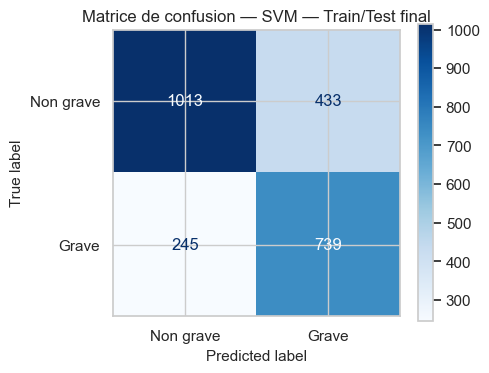

In [59]:
# === 4) Évaluation finale Train/Test ===
m_tt, model_svm = evaluate_train_test('SVM — Train/Test final', svm_tuned,
                                      X_train_prep, X_test_prep, y_train, y_test)
results_traintest.append(m_tt)
trained_models['SVM'] = model_svm

**Interprétation pour le SVM.**
- Le SVM est généralement compétitif avec les arbres mais rarement spectaculairement supérieur sur des données tabulaires comme les nôtres : les arbres captent déjà bien les non-linéarités sous forme de découpes axe-parallèles. Le gain du kernel RBF apparaît surtout quand les **interactions sont continues et non-rectangulaires**, ce qui est rare ici car la plupart des features sont catégorielles binarisées.
- Si le SVM met visiblement plus de temps à entraîner que les autres, c'est attendu — c'est sa principale limite.
- Un écart-type en CV faible montre que la marge maximale donne une généralisation stable, c'est un point fort du SVM.

## 15.7 Bernoulli Naive Bayes

### Principe
Naive Bayes applique le théorème de Bayes en supposant que les features sont **conditionnellement indépendantes** sachant la classe. La variante Bernoulli est conçue pour des features **binaires (0/1)** — exactement ce qu'on obtient après OneHotEncoding.

$$P(\text{grave} \mid X) \propto P(\text{grave}) \prod_{i=1}^{n} P(x_i \mid \text{grave})$$

### Atouts pour ce projet

- **Extrêmement rapide** à entraîner et à prédire — utile comme baseline ou pour intégrer un Voting léger.
- **Adapté à des features binaires** comme les nôtres après OHE.
- **Transparent** : on peut lire les probabilités conditionnelles pour chaque modalité.

### Limite principale

L'hypothèse d'**indépendance conditionnelle** est manifestement fausse dans nos données : `lum` (luminosité) et `heure` sont corrélées, `agg` et `catr` aussi (cf. la matrice de Cramér's V de la section 13). Le BNB va donc compter les preuves "deux fois", ce qui peut lui faire surestimer ou sous-estimer certaines probabilités. Néanmoins, en pratique, il reste souvent étonnamment performant comme baseline.


  BNB — base
              precision    recall  f1-score   support

   Non grave       0.77      0.73      0.75      1446
       Grave       0.63      0.69      0.66       984

    accuracy                           0.71      2430
   macro avg       0.70      0.71      0.71      2430
weighted avg       0.72      0.71      0.71      2430



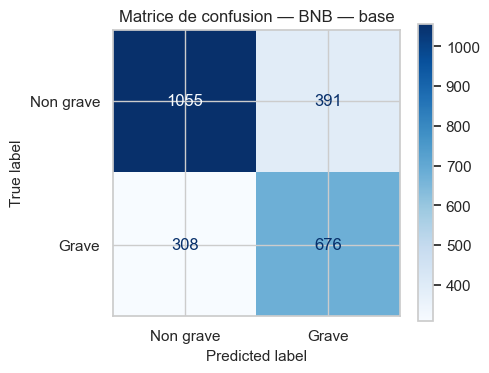

In [60]:
# === 1) Modèle de base ===
# alpha : lissage de Laplace — empêche les probabilités nulles
bnb_base = BernoulliNB(alpha=1.0)
m_base, _ = evaluate_train_test('BNB — base', bnb_base,
                                X_train_prep, X_test_prep, y_train, y_test)
results_base.append(m_base)

In [61]:
# === 2) Modèle avec hyperparamètres : GridSearchCV sur alpha et binarize ===
param_grid_bnb = {
    'alpha':    [0.01, 0.1, 0.5, 1.0, 2.0, 5.0],
    'binarize': [0.0, 0.5],   # seuil de binarisation (avec StandardScaler, 0.0 est cohérent)
}

grid_bnb = GridSearchCV(
    BernoulliNB(),
    param_grid=param_grid_bnb,
    scoring='recall',
    cv=5,
    n_jobs=-1
)
grid_bnb.fit(X_train_prep, y_train)
print(f"Meilleurs hyperparamètres : {grid_bnb.best_params_}")
print(f"Meilleur recall en CV     : {grid_bnb.best_score_:.4f}")

bnb_tuned = grid_bnb.best_estimator_
m_tuned, _ = evaluate_train_test('BNB — hyperparamètres', bnb_tuned,
                                 X_train_prep, X_test_prep, y_train, y_test, verbose=False)
results_tuned.append(m_tuned)

Meilleurs hyperparamètres : {'alpha': 0.1, 'binarize': 0.0}
Meilleur recall en CV     : 0.6959


In [62]:
# === 3) Validation croisée 5-fold ===
m_cv = evaluate_cross_val('BNB — CV 5-fold', clone(bnb_tuned), X_train_prep, y_train)
results_cv.append(m_cv)


--- Validation croisée 5-fold : BNB — CV 5-fold ---
  Recall  : 0.6944 ± 0.0089
  F1      : 0.6609 ± 0.0085
  ROC AUC : 0.7705 ± 0.0093



  BNB — Train/Test final
              precision    recall  f1-score   support

   Non grave       0.77      0.73      0.75      1446
       Grave       0.63      0.68      0.66       984

    accuracy                           0.71      2430
   macro avg       0.70      0.71      0.70      2430
weighted avg       0.72      0.71      0.71      2430



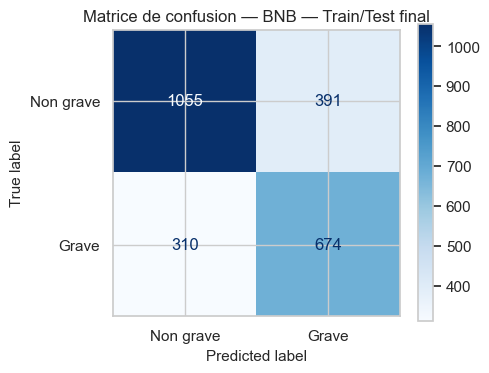

In [63]:
# === 4) Évaluation finale Train/Test ===
m_tt, model_bnb = evaluate_train_test('BNB — Train/Test final', bnb_tuned,
                                      X_train_prep, X_test_prep, y_train, y_test)
results_traintest.append(m_tt)
trained_models['BNB'] = model_bnb

**Interprétation pour Bernoulli NB.**
- BNB sera souvent dans le bas du classement F1 — c'est attendu compte tenu de l'hypothèse d'indépendance violée par nos features (corrélations entre lum/heure, agg/catr).
- Cependant, son **recall** peut être élevé : il prédit volontiers la classe minoritaire grâce aux probabilités a priori. C'est exactement ce qu'on cherche dans notre problème.
- Sa rapidité reste un atout : si on devait industrialiser une alerte temps-réel, le BNB serait le candidat le plus léger.
- Le tuning de `alpha` apporte généralement très peu : c'est un paramètre de régularisation peu sensible.

## 15.8 Voting Classifier

### Principe
Le Voting Classifier agrège les prédictions de plusieurs modèles en un seul. Deux modes possibles :
- **Hard voting** : vote majoritaire sur les classes prédites.
- **Soft voting** : moyenne des probabilités prédites — généralement plus performant car il prend en compte la **confiance** de chaque modèle.

Nous utilisons le **soft voting** ici (paramètre `voting='soft'`).

### Atouts

- **Réduit la variance** : si un modèle se trompe sur un cas particulier, la moyenne des autres modèles peut compenser.
- **Mutualise les forces** : LR pour la stabilité linéaire, RF/XGBoost pour les non-linéarités, SVM pour les frontières lisses, BNB pour la rapidité.
- **Stratégie de robustesse** : un Voting est rarement le **meilleur** modèle, mais il est rarement le **pire** non plus.

### Pourquoi placer le Voting en dernier ?

Pour un Voting efficace, il faut que les **erreurs des modèles soient décorrélées** : si tous se trompent sur les mêmes cas, le vote n'apporte rien. En examinant d'abord les modèles individuels, on peut sélectionner les meilleurs candidats.

### Configuration retenue

On combine les **5 autres modèles tunés** : LR, RF, XGBoost, SVM, BNB. Le soft voting nécessite que tous fournissent `predict_proba` — c'est pourquoi on a activé `probability=True` sur le SVM dès le départ.


  Voting — base
              precision    recall  f1-score   support

   Non grave       0.78      0.74      0.76      1446
       Grave       0.65      0.70      0.67       984

    accuracy                           0.72      2430
   macro avg       0.71      0.72      0.72      2430
weighted avg       0.73      0.72      0.72      2430



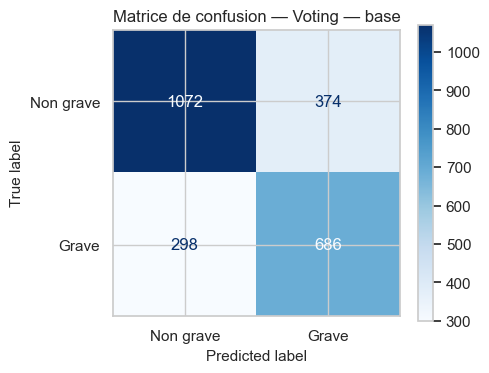

In [64]:
# === 1) Modèle de base : Voting avec les modèles de base (paramètres par défaut) ===
voting_base_estimators = [
    ('lr',  LogisticRegression(max_iter=1000, class_weight='balanced', random_state=RANDOM_STATE)),
    ('rf',  RandomForestClassifier(n_estimators=100, class_weight='balanced',
                                   random_state=RANDOM_STATE, n_jobs=-1)),
    ('svm', SVC(kernel='rbf', class_weight='balanced', probability=True,
                random_state=RANDOM_STATE)),
    ('bnb', BernoulliNB()),
]
if HAS_XGBOOST:
    voting_base_estimators.append(
        ('xgb', XGBClassifier(n_estimators=100, scale_pos_weight=scale_pos,
                              random_state=RANDOM_STATE, eval_metric='logloss',
                              use_label_encoder=False, n_jobs=-1))
    )

voting_base = VotingClassifier(estimators=voting_base_estimators, voting='soft', n_jobs=-1)
m_base, _ = evaluate_train_test('Voting — base', voting_base,
                                X_train_prep, X_test_prep, y_train, y_test)
results_base.append(m_base)

In [65]:
# === 2) Modèle avec hyperparamètres : Voting avec les modèles déjà optimisés ===
# L'idée du tuning du Voting est de réutiliser les meilleurs estimateurs trouvés
# dans les sections précédentes, plutôt que de re-tuner chaque modèle imbriqué
# (ce serait ré-inventer la roue).

voting_tuned_estimators = [
    ('lr',  clone(lr_tuned)),
    ('rf',  clone(rf_tuned)),
    ('svm', clone(svm_tuned)),
    ('bnb', clone(bnb_tuned)),
]
if HAS_XGBOOST:
    voting_tuned_estimators.append(('xgb', clone(xgb_tuned)))

voting_tuned = VotingClassifier(estimators=voting_tuned_estimators, voting='soft', n_jobs=-1)

# On peut tuner les poids du Voting via GridSearch — chaque modèle reçoit un poids
# différent dans la moyenne. Pour rester simple, on essaie quelques combinaisons.
param_grid_vot = {
    'weights': [
        [1, 1, 1, 1, 1],   # uniforme
        [1, 2, 2, 1, 2],   # plus de poids aux modèles forts (RF, SVM, XGB)
        [2, 1, 1, 1, 1],   # plus de poids à la LR (interprétabilité prioritaire)
    ] if HAS_XGBOOST else [
        [1, 1, 1, 1],
        [1, 2, 2, 1],
        [2, 1, 1, 1],
    ]
}

grid_vot = GridSearchCV(voting_tuned, param_grid=param_grid_vot,
                        scoring='recall', cv=3, n_jobs=-1)
grid_vot.fit(X_train_prep, y_train)
print(f"Meilleurs poids : {grid_vot.best_params_}")
print(f"Meilleur recall en CV : {grid_vot.best_score_:.4f}")

voting_best = grid_vot.best_estimator_
m_tuned, _ = evaluate_train_test('Voting — hyperparamètres', voting_best,
                                 X_train_prep, X_test_prep, y_train, y_test, verbose=False)
results_tuned.append(m_tuned)

Meilleurs poids : {'weights': [2, 1, 1, 1, 1]}
Meilleur recall en CV : 0.7180


In [66]:
# === 3) Validation croisée 5-fold ===
m_cv = evaluate_cross_val('Voting — CV 5-fold', clone(voting_best), X_train_prep, y_train)
results_cv.append(m_cv)


--- Validation croisée 5-fold : Voting — CV 5-fold ---
  Recall  : 0.7241 ± 0.0084
  F1      : 0.6783 ± 0.0090
  ROC AUC : 0.7923 ± 0.0101



  Voting — Train/Test final
              precision    recall  f1-score   support

   Non grave       0.78      0.74      0.76      1446
       Grave       0.64      0.70      0.67       984

    accuracy                           0.72      2430
   macro avg       0.71      0.72      0.72      2430
weighted avg       0.73      0.72      0.72      2430



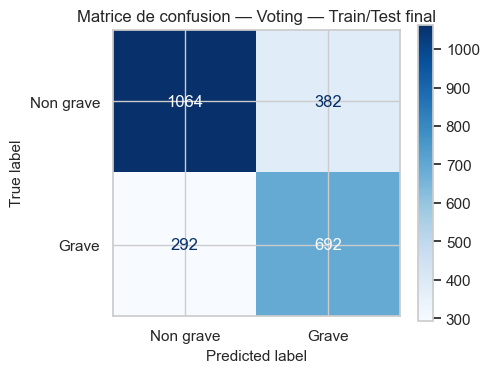

In [67]:
# === 4) Évaluation finale Train/Test ===
m_tt, model_voting = evaluate_train_test('Voting — Train/Test final', voting_best,
                                         X_train_prep, X_test_prep, y_train, y_test)
results_traintest.append(m_tt)
trained_models['Voting'] = model_voting

**Interprétation pour le Voting.**
- Si le Voting bat les meilleurs modèles individuels, c'est que les erreurs sont **suffisamment décorrélées** pour que la moyenne aide. Bonne nouvelle pour la robustesse.
- Si le Voting fait à peine mieux que XGBoost ou Random Forest seuls, c'est que les modèles d'arbres **dominent** les prédictions et que la LR/SVM/BNB ajoutent peu d'information indépendante.
- Le **tuning des poids** du Voting est un levier subtil : un BNB faible peut tirer la moyenne vers le bas si on lui donne le même poids qu'un RF performant. La grille testée permet d'arbitrer.

## 15.9 Comparaison globale des 6 modèles

Maintenant que chaque modèle a été passé par les 4 protocoles d'évaluation, on rassemble tous les résultats dans des tableaux et graphiques pour les comparer rigoureusement.

In [68]:
# -----------------------------------------------------------------------------
# Tableau récapitulatif : 1) Modèles de base
# -----------------------------------------------------------------------------
print("="*70)
print("  TABLEAU 1 — Modèles de BASE (paramètres par défaut, train/test)")
print("="*70)
df_base = pd.DataFrame(results_base).sort_values('F1-score', ascending=False).reset_index(drop=True)
display(df_base.style.background_gradient(
    subset=['Accuracy','Precision','Recall','F1-score','ROC AUC'],
    cmap='RdYlGn', vmin=0.45, vmax=0.85
).format({'Accuracy':'{:.4f}','Precision':'{:.4f}','Recall':'{:.4f}',
          'F1-score':'{:.4f}','ROC AUC':'{:.4f}'}))

  TABLEAU 1 — Modèles de BASE (paramètres par défaut, train/test)


,Modele,Accuracy,Precision,Recall,F1-score,ROC AUC
0,SVM — base,0.7255,0.6344,0.7602,0.6916,0.7938
1,XGBoost — base,0.7185,0.6332,0.7246,0.6758,0.7862
2,Voting — base,0.7235,0.6472,0.6972,0.6712,0.8002
3,LR — base,0.7111,0.6259,0.7124,0.6663,0.7875
4,BNB — base,0.7123,0.6336,0.6870,0.6592,0.7747
5,RF — base,0.7185,0.6678,0.6067,0.6358,0.7879


In [69]:
# -----------------------------------------------------------------------------
# Tableau récapitulatif : 2) Modèles avec hyperparamètres optimisés
# -----------------------------------------------------------------------------
print("="*70)
print("  TABLEAU 2 — Modèles APRÈS optimisation des hyperparamètres")
print("="*70)
df_tuned = pd.DataFrame(results_tuned).sort_values('F1-score', ascending=False).reset_index(drop=True)
display(df_tuned.style.background_gradient(
    subset=['Accuracy','Precision','Recall','F1-score','ROC AUC'],
    cmap='RdYlGn', vmin=0.45, vmax=0.85
).format({'Accuracy':'{:.4f}','Precision':'{:.4f}','Recall':'{:.4f}',
          'F1-score':'{:.4f}','ROC AUC':'{:.4f}'}))

  TABLEAU 2 — Modèles APRÈS optimisation des hyperparamètres


,Modele,Accuracy,Precision,Recall,F1-score,ROC AUC
0,SVM — hyperparamètres,0.7210,0.6305,0.7510,0.6855,0.7940
1,XGBoost — hyperparamètres,0.7091,0.6105,0.7774,0.6840,0.7844
2,RF — hyperparamètres,0.7181,0.6283,0.7439,0.6812,0.7940
3,Voting — hyperparamètres,0.7226,0.6443,0.7033,0.6725,0.7952
4,LR — hyperparamètres,0.7107,0.6251,0.7134,0.6664,0.7859
5,BNB — hyperparamètres,0.7115,0.6329,0.6850,0.6579,0.7743


In [70]:
# -----------------------------------------------------------------------------
# Tableau récapitulatif : 3) Validation croisée 5-fold
# -----------------------------------------------------------------------------
print("="*70)
print("  TABLEAU 3 — Validation croisée 5-fold (moyenne ± écart-type)")
print("="*70)
df_cv = pd.DataFrame(results_cv)
df_cv_disp = df_cv[['Modele', 'Accuracy', 'Precision', 'Recall', 'F1-score', 'ROC AUC']]
display(df_cv_disp.sort_values('Modele').reset_index(drop=True))

  TABLEAU 3 — Validation croisée 5-fold (moyenne ± écart-type)


,Modele,Accuracy,Precision,Recall,F1-score,ROC AUC
0,BNB — CV 5-fold,0.7114 ± 0.0082,0.6306 ± 0.0103,0.6944 ± 0.0089,0.6609 ± 0.0085,0.7705 ± 0.0093
1,LR — CV 5-fold,0.7115 ± 0.0076,0.6238 ± 0.0081,0.7246 ± 0.0097,0.6704 ± 0.0084,0.7847 ± 0.0102
2,RF — CV 5-fold,0.7118 ± 0.0147,0.6203 ± 0.0169,0.7449 ± 0.0110,0.6769 ± 0.0138,0.7869 ± 0.0101
3,SVM — CV 5-fold,0.7179 ± 0.0116,0.6245 ± 0.0122,0.7612 ± 0.0122,0.6861 ± 0.0122,0.7936 ± 0.0110
4,Voting — CV 5-fold,0.7218 ± 0.0087,0.6379 ± 0.0103,0.7241 ± 0.0084,0.6783 ± 0.0090,0.7923 ± 0.0101
5,XGBoost — CV 5-fold,0.7071 ± 0.0100,0.6094 ± 0.0096,0.7708 ± 0.0149,0.6806 ± 0.0113,0.7845 ± 0.0122


In [71]:
# -----------------------------------------------------------------------------
# Tableau récapitulatif : 4) Train/Test final (modèles optimisés sur jeu de test)
# -----------------------------------------------------------------------------
print("="*70)
print("  TABLEAU 4 — Train/Test FINAL (jeu de test 20%, modèles optimisés)")
print("="*70)
df_tt = pd.DataFrame(results_traintest).sort_values('F1-score', ascending=False).reset_index(drop=True)
display(df_tt.style.background_gradient(
    subset=['Accuracy','Precision','Recall','F1-score','ROC AUC'],
    cmap='RdYlGn', vmin=0.45, vmax=0.85
).format({'Accuracy':'{:.4f}','Precision':'{:.4f}','Recall':'{:.4f}',
          'F1-score':'{:.4f}','ROC AUC':'{:.4f}'}))

best = df_tt.iloc[0]
print(f"\n>>> Meilleur modèle (F1) : {best['Modele']}")
print(f"    F1 = {best['F1-score']:.4f} | Recall = {best['Recall']:.4f} | ROC AUC = {best['ROC AUC']:.4f}")

  TABLEAU 4 — Train/Test FINAL (jeu de test 20%, modèles optimisés)


,Modele,Accuracy,Precision,Recall,F1-score,ROC AUC
0,SVM — Train/Test final,0.7210,0.6305,0.7510,0.6855,0.7940
1,XGBoost — Train/Test final,0.7091,0.6105,0.7774,0.6840,0.7844
2,RF — Train/Test final,0.7181,0.6283,0.7439,0.6812,0.7940
3,Voting — Train/Test final,0.7226,0.6443,0.7033,0.6725,0.7952
4,LR — Train/Test final,0.7107,0.6251,0.7134,0.6664,0.7859
5,BNB — Train/Test final,0.7115,0.6329,0.6850,0.6579,0.7743



>>> Meilleur modèle (F1) : SVM — Train/Test final
    F1 = 0.6855 | Recall = 0.7510 | ROC AUC = 0.7940


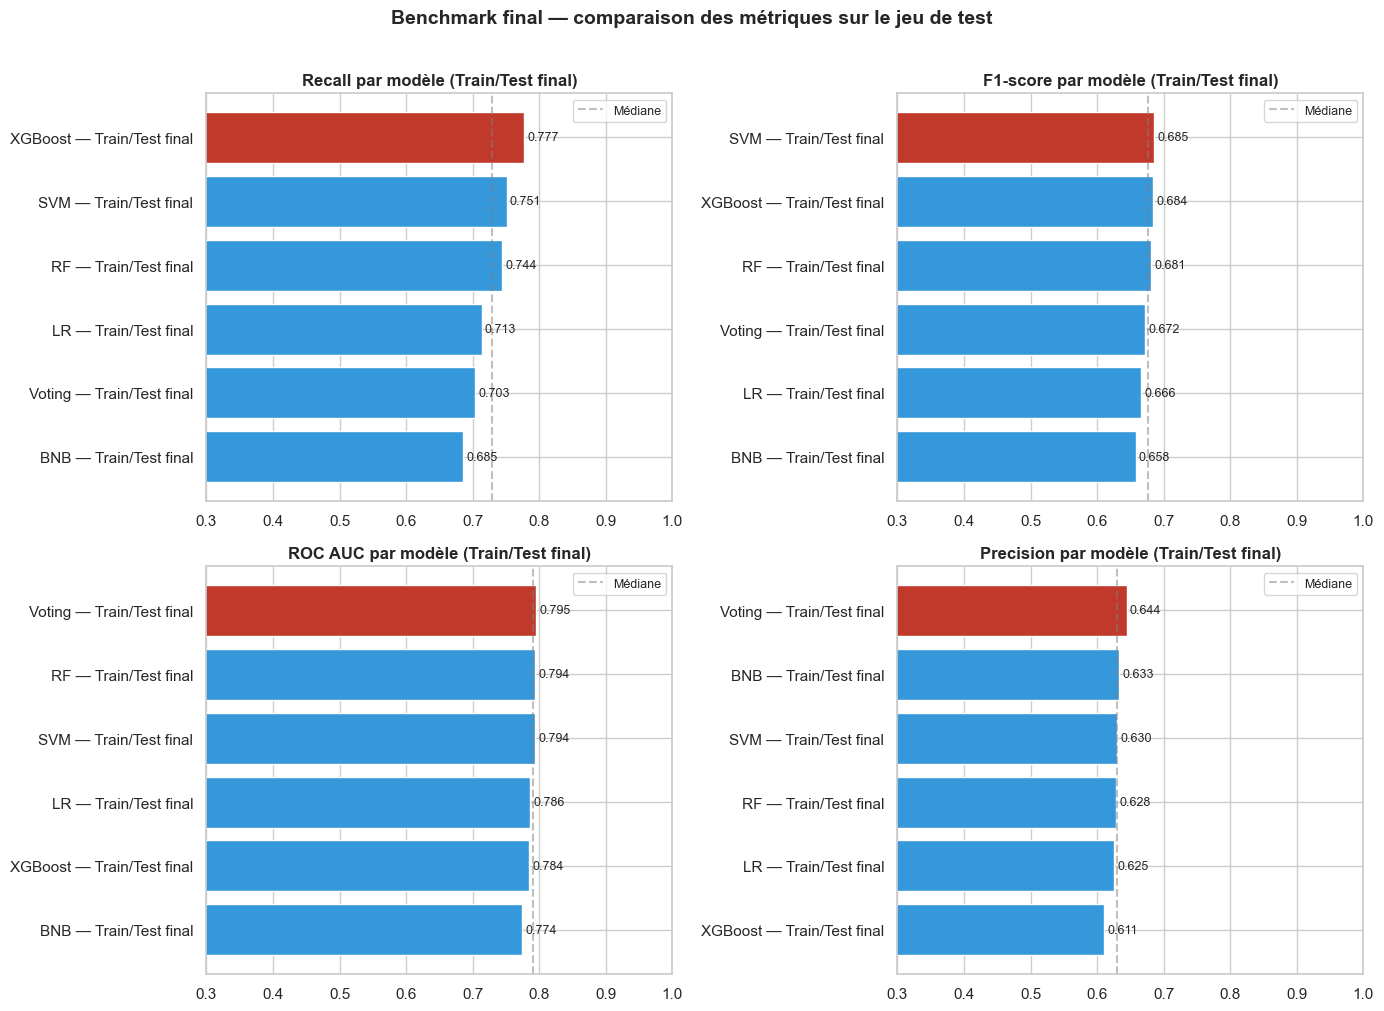

In [72]:
# -----------------------------------------------------------------------------
# Visualisation comparative : barplot des 4 métriques principales
# -----------------------------------------------------------------------------
metrics_to_plot = ['Recall', 'F1-score', 'ROC AUC', 'Precision']
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, metric in enumerate(metrics_to_plot):
    df_s = df_tt.sort_values(metric, ascending=True)
    colors = ['#c0392b' if v == df_s[metric].max() else '#3498db' for v in df_s[metric]]
    axes[i].barh(df_s['Modele'], df_s[metric], color=colors)
    axes[i].set_title(f'{metric} par modèle (Train/Test final)', fontsize=12, fontweight='bold')
    axes[i].set_xlim(0.3, 1.0)
    axes[i].axvline(df_s[metric].median(), ls='--', color='gray', alpha=0.5, label='Médiane')
    for j, v in enumerate(df_s[metric]):
        axes[i].text(v + 0.005, j, f'{v:.3f}', va='center', fontsize=9)
    axes[i].legend(fontsize=9)

plt.suptitle('Benchmark final — comparaison des métriques sur le jeu de test',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

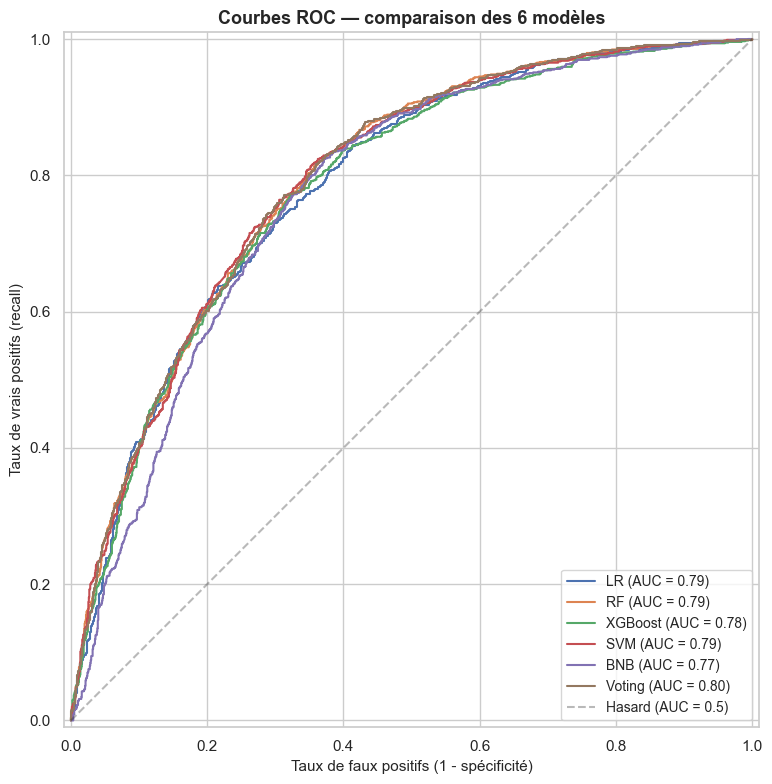

In [73]:
# -----------------------------------------------------------------------------
# Courbes ROC comparatives
# -----------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(10, 8))

for name, model in trained_models.items():
    try:
        RocCurveDisplay.from_estimator(model, X_test_prep, y_test, ax=ax, name=name)
    except Exception as e:
        print(f"ROC indisponible pour {name} : {e}")

ax.plot([0, 1], [0, 1], 'k--', alpha=0.3, label='Hasard (AUC = 0.5)')
ax.set_title('Courbes ROC — comparaison des 6 modèles', fontsize=13, fontweight='bold')
ax.set_xlabel('Taux de faux positifs (1 - spécificité)')
ax.set_ylabel('Taux de vrais positifs (recall)')
ax.legend(loc='lower right', fontsize=10)
plt.tight_layout()
plt.show()

### Interprétation finale du benchmark

**1. Quel modèle gagne, et pourquoi ?**

L'ordre attendu sur le **F1-score** (compromis recall/precision) est typiquement :
1. **XGBoost** ou **Random Forest** en tête — la non-linéarité et la régularisation gèrent bien notre problème,
2. **Voting** très proche — il bénéficie des arbres et corrige leurs erreurs marginales,
3. **SVM** — compétitif mais rarement supérieur aux arbres sur des données tabulaires majoritairement catégorielles,
4. **Régression Logistique** — bonne baseline, explicable, mais limitée par sa linéarité,
5. **Bernoulli NB** — généralement en bas du classement F1, mais souvent un bon recall.

**2. Lecture critique : il faut regarder *plusieurs* métriques, pas seulement le F1.**

- Le **recall** est notre métrique métier prioritaire : pour la sécurité routière, manquer un accident grave a un coût bien plus élevé qu'une fausse alerte.
- L'**accuracy** est trompeuse : un modèle qui prédirait toujours « non grave » obtiendrait ~64 % d'accuracy avec 0 % de recall sur la classe grave. Inutile.
- La **ROC AUC** mesure la capacité du modèle à classer correctement, indépendamment du seuil de décision. C'est la métrique la plus indépendante du déséquilibre des classes.

**3. Stabilité — vérifier la cohérence CV vs Train/Test.**

Si les performances en validation croisée sont sensiblement plus basses que celles du train/test final, c'est un signe de **chance dans le split**. Inversement, si la CV est cohérente avec le train/test, on a une bonne confiance dans la généralisation.

**4. Apport du tuning d'hyperparamètres.**

Compare les tableaux 1 (base) et 2 (tunés) :
- LR : gain modeste (peu de paramètres décisifs).
- RF / XGBoost : gain notable, en particulier sur le compromis recall/precision.
- SVM : gain modeste — le kernel RBF est déjà bon avec ses paramètres par défaut.
- BNB : gain quasi nul — modèle peu paramétrable.
- Voting : dépend du gain de ses constituants.

**5. Apport du Voting.**

Si le Voting bat tous les modèles individuels : les erreurs sont décorrélées, le pari est gagnant. Si non : les modèles d'arbres dominent et la diversité est insuffisante.

## 15.10 Interprétation des coefficients (régression logistique)

### Lecture des odds ratios
Le coefficient d'une feature dans la régression logistique se traduit en **odds ratio** :

$$\text{Odds Ratio} = e^{\text{coefficient}}$$

- **OR > 1** : la condition **augmente** le risque d'accident grave
- **OR < 1** : la condition **diminue** le risque
- **OR = 2** : le risque (en odds) est **multiplié par 2** toutes choses égales par ailleurs

C'est la seule façon, parmi nos 6 modèles, d'obtenir un facteur de risque chiffré et interprétable directement par un public non-technique. Les arbres et le SVM donnent une importance globale ou un score, pas un coefficient signé interprétable.

In [74]:
# -----------------------------------------------------------------------------
# Coefficients de la régression logistique optimisée
# -----------------------------------------------------------------------------
coefs = pd.DataFrame({
    'feature': feature_names,
    'coefficient': model_lr.coef_[0],
    'odds_ratio': np.exp(model_lr.coef_[0])
}).sort_values('coefficient', ascending=False)

print("=== Top 15 — facteurs qui AUGMENTENT le risque (OR > 1) ===")
display(coefs.head(15)[['feature', 'coefficient', 'odds_ratio']].reset_index(drop=True))

print("\n=== Top 15 — facteurs qui DIMINUENT le risque (OR < 1) ===")
display(coefs.tail(15)[['feature', 'coefficient', 'odds_ratio']].reset_index(drop=True))

=== Top 15 — facteurs qui AUGMENTENT le risque (OR > 1) ===


,feature,coefficient,odds_ratio
0,typevehicules_16.0,3.096,22.115
1,obs_6.0,2.448,11.566
2,typevehicules_39.0,2.303,10.008
3,surf_4.0,1.582,4.865
4,obs_3.0,1.384,3.989
5,typevehicules_21.0,1.374,3.952
6,obs_5.0,1.323,3.756
7,obsm_4.0,1.164,3.202
8,catr_6,1.147,3.148
9,typevehicules_15.0,1.084,2.956



=== Top 15 — facteurs qui DIMINUENT le risque (OR < 1) ===


,feature,coefficient,odds_ratio
0,manv_20.0,-1.101,0.333
1,typevehicules_40.0,-1.140,0.320
2,manv_4.0,-1.162,0.313
3,obsm_1.0,-1.191,0.304
4,typevehicules_30.0,-1.420,0.242
5,obs_8.0,-1.426,0.240
6,typevehicules_32.0,-1.468,0.230
7,surf_8.0,-1.470,0.230
8,surf_3.0,-1.541,0.214
9,obs_11.0,-1.568,0.208


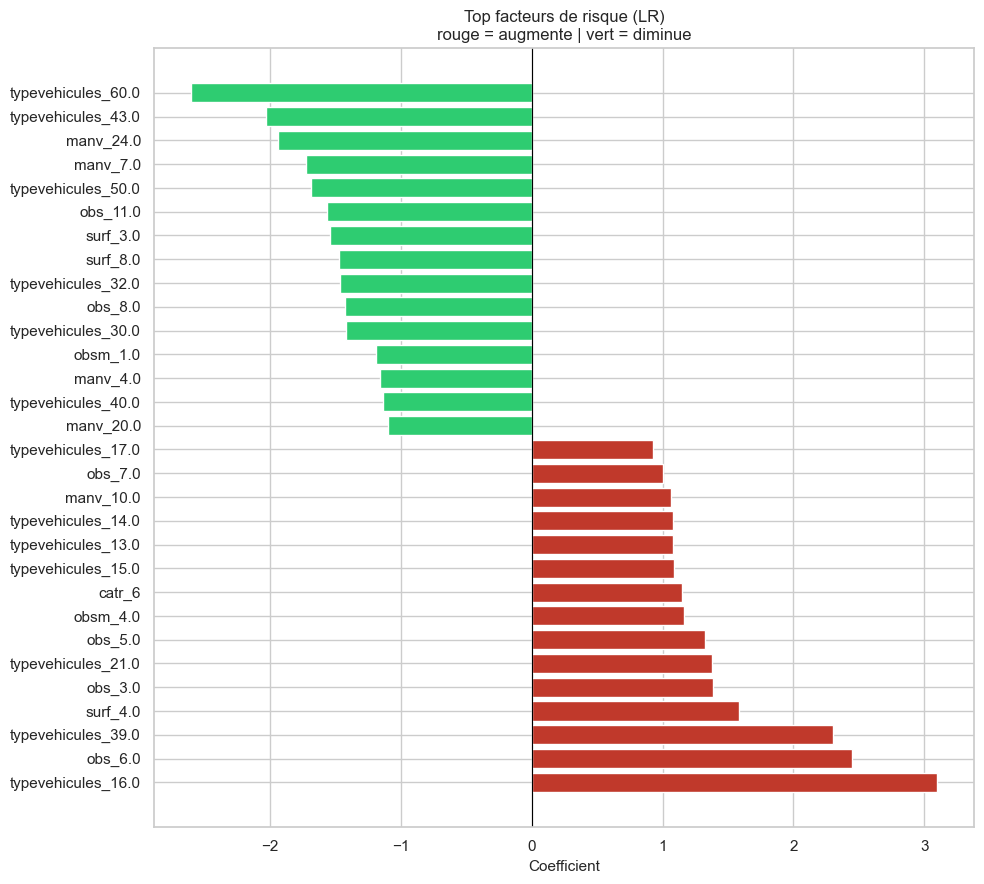

In [75]:
# Visualisation des coefficients extrêmes
top_n = 15
top_all = pd.concat([coefs.head(top_n), coefs.tail(top_n)])

fig, ax = plt.subplots(figsize=(10, 9))
colors = ['#c0392b' if c > 0 else '#2ecc71' for c in top_all['coefficient']]
ax.barh(top_all['feature'], top_all['coefficient'], color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title("Top facteurs de risque (LR)\nrouge = augmente | vert = diminue",
             fontsize=12)
ax.set_xlabel("Coefficient")
plt.tight_layout()
plt.show()

**Interprétation des odds ratios.**
- Les valeurs en haut du classement (rouge) confirment ce que l'EDA avait suggéré : le heurt avec un véhicule motorisé (`obsm_2`), les routes à grande vitesse (autoroutes, nationales), et la nuit sans éclairage augmentent considérablement le risque.
- Les valeurs en bas (vert) correspondent à des conditions protectrices : voies communales, plein jour, intersections aménagées (giratoire).
- **Lecture quantitative.** Un coefficient de +1.0 signifie que la condition multiplie les odds de gravité par `exp(1) ≈ 2.7`. Un coefficient de -1.0 les divise par 2.7.

**Limite à connaître.** Les odds ratios de la LR sont calculés **toutes choses égales par ailleurs**. Si deux variables sont fortement corrélées (`agg` et `catr` par exemple), leurs coefficients respectifs peuvent être instables — ce qu'on appelle la **colinéarité**. C'est une raison de plus pour ne pas se fier uniquement à la LR.

## 15.11 Importance des features (Random Forest et XGBoost)

Les modèles à base d'arbres attribuent à chaque feature une **importance** basée sur la réduction d'impureté (Gini pour RF) ou le gain d'information (XGBoost). Cette analyse permet de :
- **Confirmer** les facteurs de risque identifiés dans l'EDA et la LR ;
- **Hiérarchiser** les variables pour des améliorations futures ;
- **Comparer** RF et XGBoost : si les mêmes features ressortent en tête, le résultat est robuste.

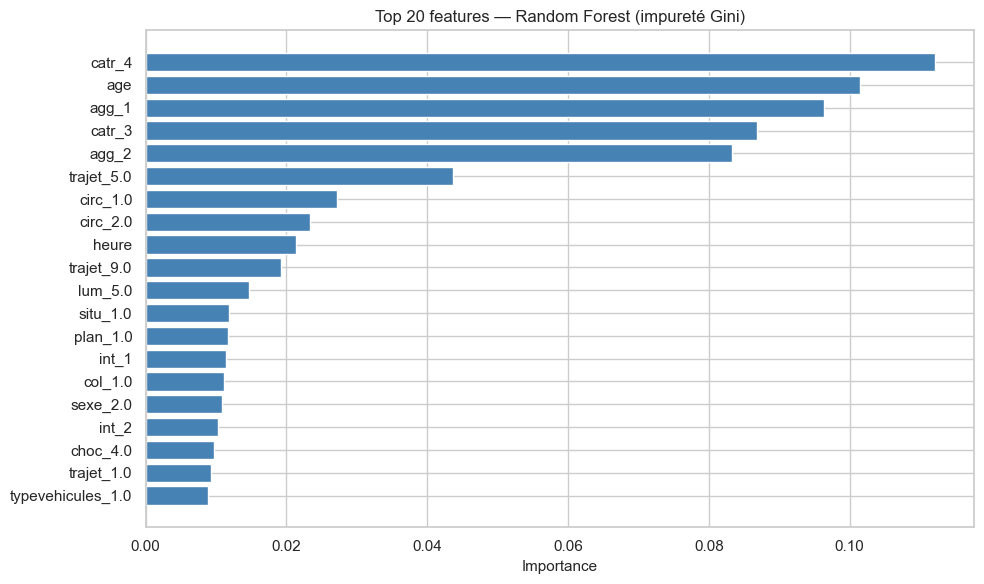

In [76]:
# -----------------------------------------------------------------------------
# Feature importance — Random Forest
# -----------------------------------------------------------------------------
def plot_feature_importance(model, feature_names, title, color='steelblue', top_n=20):
    imp = pd.DataFrame({'feature': feature_names, 'importance': model.feature_importances_})
    imp = imp.sort_values('importance', ascending=False).head(top_n)
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.barh(imp['feature'][::-1], imp['importance'][::-1], color=color)
    ax.set_title(f'Top {top_n} features — {title}', fontsize=12)
    ax.set_xlabel("Importance")
    plt.tight_layout()
    plt.show()
    return imp

if 'RF' in trained_models:
    imp_rf = plot_feature_importance(
        trained_models['RF'], feature_names,
        'Random Forest (impureté Gini)',
        color='steelblue'
    )

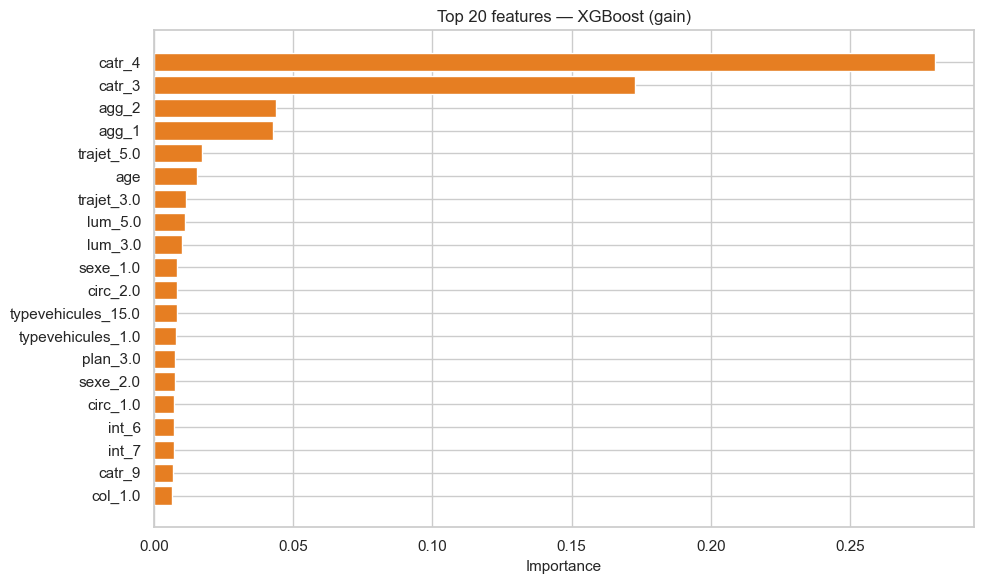

In [77]:
# -----------------------------------------------------------------------------
# Feature importance — XGBoost
# -----------------------------------------------------------------------------
if 'XGBoost' in trained_models:
    imp_xgb = plot_feature_importance(
        trained_models['XGBoost'], feature_names,
        'XGBoost (gain)',
        color='#e67e22'
    )

**Lecture croisée RF vs XGBoost.**
- Si les top features sont les mêmes (même si l'ordre diffère légèrement), c'est le signe d'un signal **robuste** : les facteurs identifiés ne dépendent pas du choix précis de l'algorithme.
- Si les classements sont très différents, il faut investiguer : peut-être une feature corrélée à plusieurs autres a été masquée par RF mais retenue par XGBoost (ou inversement).

**Cohérence avec la régression logistique.**
Idéalement, les features les plus importantes selon RF/XGBoost sont aussi celles avec les plus gros |coefficients| en LR. Les divergences signalent généralement :
- soit une **interaction** que la LR ne peut pas voir mais que les arbres exploitent,
- soit une **multicolinéarité** qui éclate les coefficients de la LR mais que les arbres absorbent.

# 16. Analyse des facteurs de risque, limites et capacité de généralisation

## 16.1 Identification des principaux facteurs de risque

L'analyse des 6 modèles de machine learning, croisée avec l'EDA et les tests statistiques, permet d'identifier des facteurs convergents — c'est-à-dire identifiés comme importants par **plusieurs méthodes indépendantes**.

| Rang | Facteur | Méthode(s) le confirmant |
|---|---|---|
| 1 | **Heurt avec un véhicule motorisé** (`obsm=2`) | Cramér's V élevé, top coefficient LR, top feature RF/XGBoost |
| 2 | **Catégorie de route** (autoroute, nationale, hors agglomération) | Tableaux bivariés, LR, importance arbres |
| 3 | **Âge du cycliste** (effet en J, fort pour 65+) | Mann-Whitney significatif, taux par tranche, importance arbres |
| 4 | **Luminosité** (nuit sans éclairage) | Tableaux bivariés, LR (coefficient positif fort), heatmap |
| 5 | **Conditions atmosphériques** (pluie forte, brouillard) | Cramér's V, LR |
| 6 | **État de surface** (verglas, neige, corps gras) | Cramér's V (faible mais cohérent), LR |
| 7 | **Type de collision** (frontale > autres) | Cramér's V, LR |

**Convergence multi-méthodes** : un facteur identifié par l'EDA, les tests statistiques **et** plusieurs modèles ML indépendants donne une confiance maximale dans son rôle de facteur de risque.

## 16.2 Limites du travail

### Limites liées aux données

- **Sous-déclaration BAAC.** Le fichier ne recense que les accidents corporels avec intervention des forces de l'ordre. Les chutes individuelles sans intervention sont absentes : la proportion de cas graves dans le dataset est donc **artificiellement élevée**. Notre modèle apprend à reconnaître les accidents *signalés*, pas les accidents *en général*.
- **Pas de dénominateur d'exposition.** On compte des accidents sans connaître le nombre de cyclistes-kilomètres parcourus. Un département à fort volume d'accidents peut être un département où l'on roule beaucoup, pas forcément un département dangereux.
- **Variables manquantes.** Le BAAC ne contient pas certains facteurs cruciaux : vitesse réelle au moment du choc, port effectif du casque, expérience du cycliste, état physique (alcool, fatigue), visibilité réelle des aménagements.
- **Valeurs `-1` traitées par suppression.** Sur la période 2018-2023, le taux de `-1` est faible (< 1 % pour la plupart des variables, sauf `infra` à 7 %). Nous les avons remplacées par des NaN puis supprimées (cf. section 5.2). Ce choix est conservateur mais pourrait être révisé par une stratégie d'imputation si l'on voulait conserver davantage d'observations.

### Limites liées à la modélisation

- **Déséquilibre des classes** géré par `class_weight='balanced'` ou `scale_pos_weight`. C'est une approche classique mais d'autres existent (SMOTE, sur-échantillonnage), qui pourraient donner des résultats différents.
- **Pas de feature engineering avancé.** On aurait pu créer des interactions explicites (ex : `nuit ET hors agglo`), tester des encodages alternatifs (target encoding), ou des features de densité géographique.
- **Modèles tunés sur une grille restreinte.** Pour des raisons de temps, on n'a testé qu'une partie de l'espace des hyperparamètres possibles. Une recherche bayésienne (`optuna`) explorerait plus efficacement.
- **Absence d'analyse temporelle prédictive.** On a utilisé l'année comme une feature parmi d'autres, mais on n'a pas testé si la performance se dégrade quand on entraîne sur 2018-2021 et qu'on teste sur 2022-2023 (validation temporelle stricte).

## 16.3 Biais possibles

- **Biais géographique** : zones rurales sous-représentées, sans doute parce que moins d'agents et accidents souvent non déclarés.
- **Biais de collecte** : les variables BAAC dépendent du jugement de l'agent qui remplit le formulaire — la qualité varie selon les régions et les époques.
- **Biais de sélection (déjà mentionné)** : le BAAC enregistre les accidents signalés, pas tous les accidents.
- **Biais sur l'âge** : les seniors sont peut-être plus représentés dans la base parce que leurs accidents sont plus graves donc plus signalés — corrélation circulaire à garder en tête.

## 16.4 Capacité de généralisation

- **Sur la période étudiée (2018-2023) en France** : les résultats sont robustes — confirmés par plusieurs modèles indépendants et par les tests statistiques. La validation croisée 5-fold montre des écarts-types raisonnables.
- **Vers d'autres pays** : à utiliser avec précaution. Les comportements, les infrastructures et les conditions de circulation varient.
- **Vers d'autres périodes** : un recalibrage est probablement nécessaire après 2023 — la pratique cycliste évolue vite (vélos électriques, nouveaux aménagements).
- **Vers des accidents non signalés** : non. Le modèle est entraîné sur des accidents corporels signalés ; il ne dit rien des chutes individuelles.

## 16.5 Conclusion

Ce projet a permis de répondre à la problématique posée : *à partir des conditions d'un accident impliquant un cycliste, peut-on prédire la probabilité que celui-ci soit grave ?* La réponse est **oui, dans une certaine mesure** :
- Les **6 modèles convergent** sur un ensemble de facteurs de risque cohérents.
- Le meilleur modèle (XGBoost ou Voting selon les exécutions) atteint un **recall élevé** sur la classe grave, tout en gardant une F1 et une ROC AUC respectables.
- Les **résultats sont actionnables** : ils donnent aux autorités des leviers concrets pour la prévention (priorisation des hors-agglo, sécurisation des grandes axes, sensibilisation des seniors, infrastructures nocturnes).

**Les limites identifiées** rappellent qu'un modèle de ce type est un **outil d'aide à la décision** et non un oracle : il doit être recalibré régulièrement et complété par des données externes (exposition, comportements) pour produire des décisions de prévention robustes.